In [291]:
import math
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 0. Import Datasets:

In [292]:
customers_db = pd.read_csv("data/DM_AIAI_CustomerDB.csv", sep=",", index_col=0)
flights_db = pd.read_csv("data/DM_AIAI_FlightsDB.csv", sep=",")

In [293]:
customers_db.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [294]:
customers_db.shape

(16921, 20)

In [295]:
flights_db.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [296]:
flights_db.shape

(608436, 10)

- **Customers database has 16921 rows and 20 columns**
- **flights database has 608436 rows and 9 columns**

# 1. Analysis of each table separately:

## 1.1. CustomersDB:

### 1.1.3. Descriptives:

In [297]:
cols_customers = customers_db.columns.values
print(cols_customers)

['Loyalty#' 'First Name' 'Last Name' 'Customer Name' 'Country'
 'Province or State' 'City' 'Latitude' 'Longitude' 'Postal code' 'Gender'
 'Education' 'Location Code' 'Income' 'Marital Status' 'LoyaltyStatus'
 'EnrollmentDateOpening' 'CancellationDate' 'Customer Lifetime Value'
 'EnrollmentType']


In [298]:
customers_db.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,259251.503597,100011.0,326823.0,550896.0,772438.0,999999.0
First Name,16921,4941,Stacey,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Salberg,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Emma Martin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578
Postal code,16921,75,V6E 3D9,917,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Population size = 16921 customers**

---

**Loyalty#:**
- 16,921 rows and 16,757 unique: 164 repeated IDs.
- Implication: 1-customer-1-row rule is violated for repeated IDs.

**Customer_Name:**
- Cardinality: 16,921 unique (top has freq 1).
- Implication: appears unique per row. (customerID)

**Country:**
- Only 1 unique value: Canada.
- Implication: Field is not representative.

**Province or State:**
- Unique: 11; top: Ontario (5,468).

**City:**
- Unique: 29; top: Toronto (3,390).

**Latitude / Longitude:**
- Lat mean (≈47.17), IQR ~44.23–49.28, 
- Lon mean (≈−91.81), IQR ~−120.24–−74.60; 
- Implication: values look plausible. Ranges stay within Canada bounds.

**Postal code:**
- Unique: 75 for 16,921 customers; top: V6E 3D9 (917).
- Implication: strong reuse of a small set of postcodes (likely area/office codes, not individualized addresses).

**Gender:**
- Unique: 2; top: female (8,497).
- Implication: near-balanced.

**Education:**
- Unique: 5; top: Bachelor (10,586).
- Implication: Higher-education skew.

**Location Code:**
- Unique: 3; top: Suburban (5,716).

**Income:**
- Count: 16,901 (20 missing); Q1=0; max ≈ 99,981; sd = 30368,992499
- Implication: zeros present (true zeros or placeholders) and wide spread.

**Marital Status:**
- Unique: 3; top: Married (9,842).
- Implication: Most customers are married. 

**LoyaltyStatus:**
- Unique: 3; top: Star (7,761).
- Implication: Tier membership is skewed toward Star, suggesting many customers sit in the top tier.

**EnrollmentDateOpening:**
- Count: 16,921 (no missing).
- Timeline: min 2015-01-27, median ~2018-10-31, 75% ≥ 2020-07-09, max 2021-12-30.
- Implication: The customer base spans cohorts from 2015 to 2021, with a sizable recent wave after mid-2020. Tenure varies widely.

**CancellationDate:**
- Count shown: 914 present (majority missing: active customers).
- Timeline (present values): 2015-12-09 to 2021-12-12 (IQR around 2019–2021).
- Missing values: active customers.  
- Implication: Only a small slice of customers show a cancellation date, and those dates cluster between 2019 and 2021. The dataset is dominated by active customers.

**Customer Lifetime Value:**
- Count: 16,901 (20 missing); median ≈ 5780.18; Q3= 8945.69; max= 83325.38
- Implication: CLV is strongly right-skewed, indicating a small subset of very high-value customers. 

**EnrollmentType:**
- Unique: 2; top: Standard (15,773).
- Implication: Most customers signed up via the standard enrollment type, and only a small slice via 2021 promotion. (class imbalance).
- Confounding problem: The label '2021 promotion' implies those customers likely joined 2021. If we just compare standard vs promotion, we might attribute those differences to the channel, when they're actually due to when people enrolled. 
 

In [299]:
customers_db.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16921 entries, 0 to 19
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loyalty#                 16921 non-null  int64  
 1   First Name               16921 non-null  object 
 2   Last Name                16921 non-null  object 
 3   Customer Name            16921 non-null  object 
 4   Country                  16921 non-null  object 
 5   Province or State        16921 non-null  object 
 6   City                     16921 non-null  object 
 7   Latitude                 16921 non-null  float64
 8   Longitude                16921 non-null  float64
 9   Postal code              16921 non-null  object 
 10  Gender                   16921 non-null  object 
 11  Education                16921 non-null  object 
 12  Location Code            16921 non-null  object 
 13  Income                   16901 non-null  float64
 14  Marital Status           16921

**Wrong Datatypes:**
- **Loyalty#** - From int64 to string
- **EnrollmentDateOpening** - From object to date
- **CancellationDate** - From object to date

### 1.1.1. Datatypes:

In [300]:
# Convert loyalty# to string:
#customers_db["Loyalty#"] = customers_db["Loyalty#"].astype("string")

# Convert EnrollmentDateOpening and CancellationDate to datetime:
customers_db[['EnrollmentDateOpening','CancellationDate']] = customers_db[['EnrollmentDateOpening','CancellationDate']].apply(lambda s: pd.to_datetime(s, errors='coerce'))

In [301]:
customers_db.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16921 entries, 0 to 19
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Loyalty#                 16921 non-null  int64         
 1   First Name               16921 non-null  object        
 2   Last Name                16921 non-null  object        
 3   Customer Name            16921 non-null  object        
 4   Country                  16921 non-null  object        
 5   Province or State        16921 non-null  object        
 6   City                     16921 non-null  object        
 7   Latitude                 16921 non-null  float64       
 8   Longitude                16921 non-null  float64       
 9   Postal code              16921 non-null  object        
 10  Gender                   16921 non-null  object        
 11  Education                16921 non-null  object        
 12  Location Code            16921 non-null 

### 1.1.2. Duplicates:

In [302]:
nr_full_duplicates_customers = customers_db.duplicated(keep=False).sum()
print(f"Total number of full duplicates: {nr_full_duplicates_customers}")

Total number of full duplicates: 0


In [303]:
nr_full_duplicates_customers = customers_db.duplicated(keep=False).sum()
total_rows = len(customers_db)
pct_full_duplicates = (nr_full_duplicates_customers / total_rows) * 100

print(f"Total number of full duplicates: {nr_full_duplicates_customers} "
      f"({pct_full_duplicates:.2f}%)")

Total number of full duplicates: 0 (0.00%)


**There are no full duplicate records.**

### 1.1.3. Missing Values:

In [304]:
total_missing = customers_db.isna().sum().sum()
total_missing_pct = (total_missing / flights_db.size) * 100  

print(f"Total missing values: {total_missing:,} ({total_missing_pct:.2f}%) ")

missing_by_col = (
    customers_db.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: d["missing_count"] / len(customers_db) * 100)
    .sort_values("missing_pct", ascending=False)
)

print("\nMissing values by column (count and % of rows):")
print(missing_by_col)

Total missing values: 14,653 (0.24%) 

Missing values by column (count and % of rows):
                         missing_count  missing_pct
CancellationDate                 14613    86.360144
Income                              20     0.118196
Customer Lifetime Value             20     0.118196
Loyalty#                             0     0.000000
Customer Name                        0     0.000000
Last Name                            0     0.000000
First Name                           0     0.000000
Country                              0     0.000000
Longitude                            0     0.000000
Province or State                    0     0.000000
City                                 0     0.000000
Latitude                             0     0.000000
Education                            0     0.000000
Gender                               0     0.000000
Postal code                          0     0.000000
Location Code                        0     0.000000
LoyaltyStatus                

Let's check if missing values for Income and Customer Lifetime Value are for the same customers:

In [305]:
m_income = customers_db["Income"].isna()
m_clv = customers_db["Customer Lifetime Value"].isna()

both_missing_mask = m_income & m_clv
both_missing = customers_db.loc[both_missing_mask]

n = len(customers_db)  
print(f"Rows with both Income and Customer Lifetime Value missing: {both_missing.shape[0]}")
print(f"% both Income and Customer Lifetime Value missing: {both_missing.shape[0] / n * 100:.2f}%")

Rows with both Income and Customer Lifetime Value missing: 20
% both Income and Customer Lifetime Value missing: 0.12%


### 1.1.4. Unique Values:

In [306]:
for column in customers_db.columns:
    unique_values = customers_db[column].unique()
    unique_values_num = customers_db[column].nunique()
    print(f"Unique values in '{column}':")
    print(unique_values)
    print(f"Number of unique values in '{column}':")
    print(unique_values_num)
    
    print()

Unique values in 'Loyalty#':
[480934 549612 429460 ... 100014 100015 100016]
Number of unique values in 'Loyalty#':
16757

Unique values in 'First Name':
['Cecilia' 'Dayle' 'Necole' ... 'Juliann' 'Olivia' 'Liam']
Number of unique values in 'First Name':
4941

Unique values in 'Last Name':
['Householder' 'Menez' 'Hannon' ... 'Bennett' 'Wilson' 'Martin']
Number of unique values in 'Last Name':
15404

Unique values in 'Customer Name':
['Cecilia Householder' 'Dayle Menez' 'Necole Hannon' ... 'Amelia Bennett'
 'Benjamin Wilson' 'Emma Martin']
Number of unique values in 'Customer Name':
16921

Unique values in 'Country':
['Canada']
Number of unique values in 'Country':
1

Unique values in 'Province or State':
['Ontario' 'Alberta' 'British Columbia' 'Quebec' 'Yukon' 'New Brunswick'
 'Manitoba' 'Nova Scotia' 'Saskatchewan' 'Newfoundland'
 'Prince Edward Island']
Number of unique values in 'Province or State':
11

Unique values in 'City':
['Toronto' 'Edmonton' 'Vancouver' 'Hull' 'Whitehorse' 'T

### 1.1.4. Data inconsistencies:

#### Different customers with same loyalty#:

In [307]:
# rows with duplicated Loyalty#:
duplicated_loyalty_ids = customers_db.duplicated(subset=["Loyalty#"], keep=False)

# number of distinct Loyalty# that are duplicated:
num_ids_dup = customers_db.loc[duplicated_loyalty_ids, "Loyalty#"].nunique()
print(f"Total number of distinct Loyalty# with duplicated values: {num_ids_dup}")

# % of distinct Loyalty# that are duplicated:
dup_ids_pct = num_ids_dup / customers_db["Loyalty#"].nunique() * 100

print(f"% of distinct Loyalty# with duplicated values: {dup_ids_pct:.2f}%")


Total number of distinct Loyalty# with duplicated values: 163
% of distinct Loyalty# with duplicated values: 0.97%


Let's understand if these records are true duplicates:

In [308]:
dupes = (
    customers_db
      .loc[customers_db.duplicated(subset=["Loyalty#"], keep=False)]
      .sort_values(["Loyalty#"])
)

dupes.head(20)

# Drop customers, and drop loyalty nr from flightsdb

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
1646,101902,Hans,Schlottmann,Hans Schlottmann,Canada,Ontario,London,42.984924,-81.245277,M5B 3E4,female,College,Rural,0.0,Married,Aurora,2020-01-07,NaT,6265.34,Standard
2668,101902,Yi,Nesti,Yi Nesti,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,female,Bachelor,Urban,79090.0,Married,Aurora,2020-03-19,NaT,8609.16,Standard
15988,106001,Maudie,Hyland,Maudie Hyland,Canada,New Brunswick,Fredericton,45.963589,-66.643112,E3B 2H2,female,Master,Suburban,14973.0,Divorced,Star,2015-07-16,NaT,12168.74,Standard
700,106001,Ivette,Peifer,Ivette Peifer,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,female,High School or Below,Suburban,10037.0,Single,Star,2016-01-11,NaT,4914.04,Standard
13053,106509,Stacy,Schwebke,Stacy Schwebke,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,female,College,Suburban,0.0,Single,Star,2021-06-12,NaT,4661.98,Standard
9413,106509,Ardelia,Whitehorse,Ardelia Whitehorse,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Rural,30915.0,Married,Nova,2020-04-25,2021-10-07,16727.77,Standard
9604,112142,Marty,Kijak,Marty Kijak,Canada,Nova Scotia,Halifax,44.648766,-63.575237,B3J 9S2,female,College,Suburban,0.0,Married,Nova,2020-02-21,2021-04-22,21578.86,Standard
3678,112142,Arnold,Cantoran,Arnold Cantoran,Canada,Ontario,Thunder Bay,48.380894,-89.247681,K8T 5M5,male,Bachelor,Urban,83589.0,Single,Aurora,2018-07-26,NaT,16272.74,Standard
5253,114414,Kala,Bachor,Kala Bachor,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,male,College,Rural,0.0,Married,Nova,2015-11-06,NaT,3591.07,Standard
11411,114414,Temple,Resper,Temple Resper,Canada,Ontario,Ottawa,45.421532,-75.697189,K1F 2R2,female,High School or Below,Urban,14151.0,Single,Star,2015-12-18,NaT,2617.70,Standard


- **Records with the duplicate Loyalty# belong to different customers.** 
- **1 loyalty number is assigned to more than one customer.**

In [309]:
# Assuming Loyalty# is already converted to string type

# 1. Identify all rows that are part of a duplicate set (keep=False)
dupes_df = customers_db.loc[customers_db.duplicated(subset=['Loyalty#'], keep=False)]

# 2. Extract the unique Loyalty# values from this subset and store them in a list/set
duplicate_loyalty_nrs = dupes_df['Loyalty#'].unique()

print(f"Number of unique duplicate Loyalty# identified: {len(duplicate_loyalty_nrs)}")

Number of unique duplicate Loyalty# identified: 163


In [310]:
initial_customer_rows = customers_db.shape[0]

# Filter customers_db: keep only rows where the Loyalty# is NOT in the duplicate list
customers_db = customers_db[~customers_db['Loyalty#'].isin(duplicate_loyalty_nrs)].copy()

dropped_customer_rows = initial_customer_rows - customers_db.shape[0]

print(f"Total customer records dropped: {dropped_customer_rows}")
print(f"New number of rows in customers_db: {customers_db.shape[0]}")

Total customer records dropped: 327
New number of rows in customers_db: 16594


In [311]:
initial_flight_rows = flights_db.shape[0]

# Filter flights_db: keep only rows where the Loyalty# is NOT in the duplicate list
flights_db = flights_db[~flights_db['Loyalty#'].isin([duplicate_loyalty_nrs])].copy()

dropped_flight_rows = initial_flight_rows - flights_db.shape[0]

print(f"Total flight records dropped: {dropped_flight_rows}")
print(f"New number of rows in flights_db: {flights_db.shape[0]}")

Total flight records dropped: 0
New number of rows in flights_db: 608436


### Country:

Since country has only 1 unique value (Canada), it's not a representative field, so we can remove it from our dataset.

In [312]:
customers_db.drop(columns="Country", inplace=True)

### Postal Code - structure:

Canada Postal Code Rules:
- Letter Digit Letter [space] Digit Letter Digit,

Allowed letters:
- 1st: A B C E G H J K L M N P R S T V X Y
- 3rd/5th: any of the above plus W Z (i.e., exclude D F I O Q U)

In [313]:
# No need to check for correct postal codes

""" # 1) Normalization helper
def normalize_postal(s: pd.Series) -> pd.Series:
    out = s.astype("string").str.upper().str.strip()
    out = out.str.replace(r"\s+", " ", regex=True)          
    out = out.str.replace(r"^([A-Z]\d[A-Z])\s?(\d[A-Z]\d)$", r"\1 \2", regex=True) 
    return out

# 2) Validation helpers
FIRST_OK = set(list("ABCEGHJKLMNPRSTVXY"))  # allowed 1st letter
LETTER_OK = set(list("ABCEGHJKLMNPRSTVWXYZ"))  # allowed letters at 3rd/5th

def postal_reason(pc: str) -> str:
    #Return '' if valid; otherwise a short reason.
    if pc is None or pd.isna(pc):
        return "missing"

    pc = str(pc).strip().upper().replace("  ", " ")
    # Remove a space to check positions uniformly
    pc_no_space = pc.replace(" ", "")
    if len(pc_no_space) != 6:
        return "wrong length"

    a1, n2, a3, n4, a5, n6 = pc_no_space[0], pc_no_space[1], pc_no_space[2], pc_no_space[3], pc_no_space[4], pc_no_space[5]

    if a1 not in FIRST_OK:
        return "invalid first letter"
    if not n2.isdigit():
        return "pos2 must be digit"
    if a3 not in LETTER_OK:
        return "invalid 3rd letter"
    if not n4.isdigit():
        return "pos4 must be digit"
    if a5 not in LETTER_OK:
        return "invalid 5th letter"
    if not n6.isdigit():
        return "pos6 must be digit"

    # Space format (optional but we enforce single space if any)
    if " " in pc and not re.fullmatch(r"[A-Z]\d[A-Z] \d[A-Z]\d", pc):
        return "spacing format"
    # All good
    return ""

# 3) Apply normalization + validation
pc_raw = customers_db["Postal code"]
pc_norm = normalize_postal(pc_raw)

reasons = pc_norm.map(postal_reason)
valid_mask = reasons.eq("")  # empty reason => valid

# 4) Summary
total = len(customers_db)
num_valid = valid_mask.sum()
num_invalid = total - num_valid
print(f"Valid postal codes:   {num_valid:,} ({num_valid/total*100:.2f}%)")
print(f"Invalid postal codes: {num_invalid:,} ({num_invalid/total*100:.2f}%)")

# 5) Breakdown of invalid reasons
reason_counts = reasons[~valid_mask].value_counts().sort_values(ascending=False)
print("\nInvalid reasons (top):")
print(reason_counts)

# 6) Inspect invalid rows (sample)
invalid_rows = (
    customers_db.loc[~valid_mask, ["Loyalty#","Customer Name","Province or State","City","Postal code"]]
    .assign(PostalCode_Normalized=pc_norm[~valid_mask], Reason=reasons[~valid_mask])
)
invalid_rows.head(20)
 """

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/1380357295.py:6: SyntaxWarning: invalid escape sequence '\s'
  out = out.str.replace(r"\s+", " ", regex=True)


' # 1) Normalization helper\ndef normalize_postal(s: pd.Series) -> pd.Series:\n    out = s.astype("string").str.upper().str.strip()\n    out = out.str.replace(r"\\s+", " ", regex=True)          \n    out = out.str.replace(r"^([A-Z]\\d[A-Z])\\s?(\\d[A-Z]\\d)$", r"\x01 \x02", regex=True) \n    return out\n\n# 2) Validation helpers\nFIRST_OK = set(list("ABCEGHJKLMNPRSTVXY"))  # allowed 1st letter\nLETTER_OK = set(list("ABCEGHJKLMNPRSTVWXYZ"))  # allowed letters at 3rd/5th\n\ndef postal_reason(pc: str) -> str:\n    #Return \'\' if valid; otherwise a short reason.\n    if pc is None or pd.isna(pc):\n        return "missing"\n\n    pc = str(pc).strip().upper().replace("  ", " ")\n    # Remove a space to check positions uniformly\n    pc_no_space = pc.replace(" ", "")\n    if len(pc_no_space) != 6:\n        return "wrong length"\n\n    a1, n2, a3, n4, a5, n6 = pc_no_space[0], pc_no_space[1], pc_no_space[2], pc_no_space[3], pc_no_space[4], pc_no_space[5]\n\n    if a1 not in FIRST_OK:\n        

### Income < 0:

In [314]:
pct_zero_all = (customers_db["Income"] < 0).mean() * 100
print(f"% of records with Income < 0: {pct_zero_all:.2f}%")

% of records with Income < 0: 0.00%


### Customer Name:

In [315]:
full_name = (customers_db["First Name"] + " " + customers_db["Last Name"])==customers_db["Customer Name"]

print(f"First Name + Last Name is the same as the Customer Name: "
      f"{full_name.sum()} / {len(customers_db)} "
      f"({full_name.mean()*100:.2f}%)")

First Name + Last Name is the same as the Customer Name: 16594 / 16594 (100.00%)


Since the First Name and Last Name columns together hold the same information as the customer name column, we will remove them and keep only customer name.

In [316]:
customers_db.drop(columns=["First Name", "Last Name"], inplace=True)

### Date inconsistencies:

In [317]:
# Cancellation before enrollment:
bad_order_strict = customers_db["CancellationDate"].notna() & (
    customers_db["CancellationDate"] < customers_db["EnrollmentDateOpening"]
)
bad_order_count = bad_order_strict.sum()
bad_order_pct_all = bad_order_strict.mean() * 100  

print(f"Cancellation before enrollment: {bad_order_count} rows "
      f"({bad_order_pct_all:.3f}%)")

# Enrollment or cancellation in the future:
today = pd.Timestamp.today().normalize()
future_enroll = customers_db["EnrollmentDateOpening"] > today
future_cancel = customers_db["CancellationDate"] > today

future_enroll_count = future_enroll.sum()
future_cancel_count = future_cancel.sum()

print(f"Enrollment in the future: {future_enroll_count} rows "
      f"({future_enroll.mean() * 100:.3f}%)")
print(f"Cancellation in the future: {future_cancel_count} rows "
      f"({future_cancel.mean() * 100:.3f}%)")

Cancellation before enrollment: 199 rows (1.199%)
Enrollment in the future: 0 rows (0.000%)
Cancellation in the future: 0 rows (0.000%)


- **There are 121 (0.715%) of records in which cancellation date occurs before than enrollment date.**

In [318]:
# Store initial row count for verification
initial_rows = customers_db.shape[0]

# Define the condition for rows to drop:
# 1. The customer has a CancellationDate (i.e., not NaT).
# 2. That CancellationDate is chronologically *before* the EnrollmentDateOpening.
condition_to_drop = (
    customers_db["CancellationDate"].notna()
) & (
    customers_db["CancellationDate"] < customers_db["EnrollmentDateOpening"]
)

# Filter the DataFrame to keep only the rows where the condition is False (~)
# This directly updates your 'customers_db' variable.
customers_db = customers_db[~condition_to_drop].copy()

# Calculate and report the number of dropped rows
dropped_rows = initial_rows - customers_db.shape[0]

print(f"Total rows dropped due to date inconsistency: {dropped_rows}")
print(f"New number of rows in customers_db: {customers_db.shape[0]}")

Total rows dropped due to date inconsistency: 199
New number of rows in customers_db: 16395


### 1.1.5. Feature Engineering:

#### 1.1.5.1. IsCancelled:

In [319]:
customers_db["IsCancelled"] = customers_db["CancellationDate"].notna().astype(int)

#### 1.1.5.2. Tenure_months:

In [320]:
# Tenure in months:
today = pd.Timestamp.today().normalize()

tenure_if_cancelled_days = (customers_db["CancellationDate"] - customers_db["EnrollmentDateOpening"]).dt.days
tenure_if_active_days    = (today - customers_db["EnrollmentDateOpening"]).dt.days

tenure_days = tenure_if_cancelled_days.where(customers_db["IsCancelled"].eq(1), tenure_if_active_days)

# Decimal months:
customers_db["Tenure_months"] = (tenure_days / 30).round(1)


#### 1.1.5.3. CLV_per_income:

How much value the company captures relative to the customer's income.

In [321]:
customers_db["IncomeZero_flag"] = (customers_db["Income"] == 0).astype(int)
customers_db["IncomeNA_flag"]   = customers_db["Income"].isna().astype(int)

# CLV_per_income:
customers_db["CLV_per_income"] = np.where(
    customers_db["Income"] > 0,
    (customers_db["Customer Lifetime Value"] / customers_db["Income"]) * 100,
    np.nan
).astype(float)
# correlation

In [322]:
customers_db.head(10)

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,IsCancelled,Tenure_months,IncomeZero_flag,IncomeNA_flag,CLV_per_income
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,Star,2019-02-15,NaT,3839.14,Standard,0,81.3,0,0,5.473070
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,Star,2019-03-09,NaT,3839.61,Standard,0,80.5,1,0,NaN
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,Star,2017-07-14,2021-01-08,3839.75,Standard,1,42.5,1,0,NaN
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,Star,2016-02-17,NaT,3839.75,Standard,0,117.7,1,0,NaN
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,Star,2017-10-25,NaT,3842.79,2021 Promotion,0,97.2,0,0,3.927948
6,927943,Hue Sellner,Ontario,Toronto,43.653225,-79.383186,P5S 6R4,female,College,Urban,...,Star,2017-06-09,NaT,3857.95,Standard,0,101.8,1,0,NaN
7,188893,Nakia Cash,Ontario,Trenton,44.101128,-77.576309,K8V 4B2,male,Bachelor,Suburban,...,Star,2019-12-08,NaT,3861.49,Standard,0,71.4,0,0,4.140031
8,852392,Arlene Conterras,Quebec,Montreal,45.501690,-73.567253,H2Y 2W2,female,Bachelor,Suburban,...,Star,2018-05-30,NaT,3861.49,Standard,0,90.0,0,0,4.140031
9,866307,Dustin Recine,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Suburban,...,Star,2019-10-14,NaT,3861.49,Standard,0,73.2,0,0,4.140031
10,932823,Jeremy Dickason,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,female,Bachelor,Suburban,...,Star,2018-03-17,NaT,3863.31,Standard,0,92.4,0,0,8.185152


In [323]:
print(f"Almost {round((customers_db["CLV_per_income"].isna().sum()/customers_db.shape[0])*100, 2)}% data is missing in the CLV_per_income column")

Almost 25.43% data is missing in the CLV_per_income column


### 1.1.6. Visualizations:

#### 1.1.6.1 Univariate Analysis:

##### 1.1.6.1.1. Metric Features:

In [324]:
metric_features = ["Income", "Customer Lifetime Value", "Latitude", "Longitude", "Tenure_months", "CLV_per_income"]

In [325]:
non_metric_features = [
    "Province or State",
    "City",
    "Postal code",
    "Gender",
    "Education",
    "Location Code",
    "Marital Status",
    "LoyaltyStatus",
    "EnrollmentType",
    "IsCancelled"
]

In [326]:
def plot_histograms_side_by_side(df, cols, bins=30, figsize=(12, 4)):
    
    n = len(cols)
    if n == 0:
        return

    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c]  
        nan_count = s.isna().sum()
        total = len(s)

        ax.hist(s, bins=bins, edgecolor="black")  
        ax.set_title(f"Histogram of {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25)
        ax.text(
            0.99, 0.95,
            f"NaNs: {nan_count/total*100:.2f}%",
            transform=ax.transAxes, ha="right", va="top"
        )

    plt.tight_layout()
    plt.show()


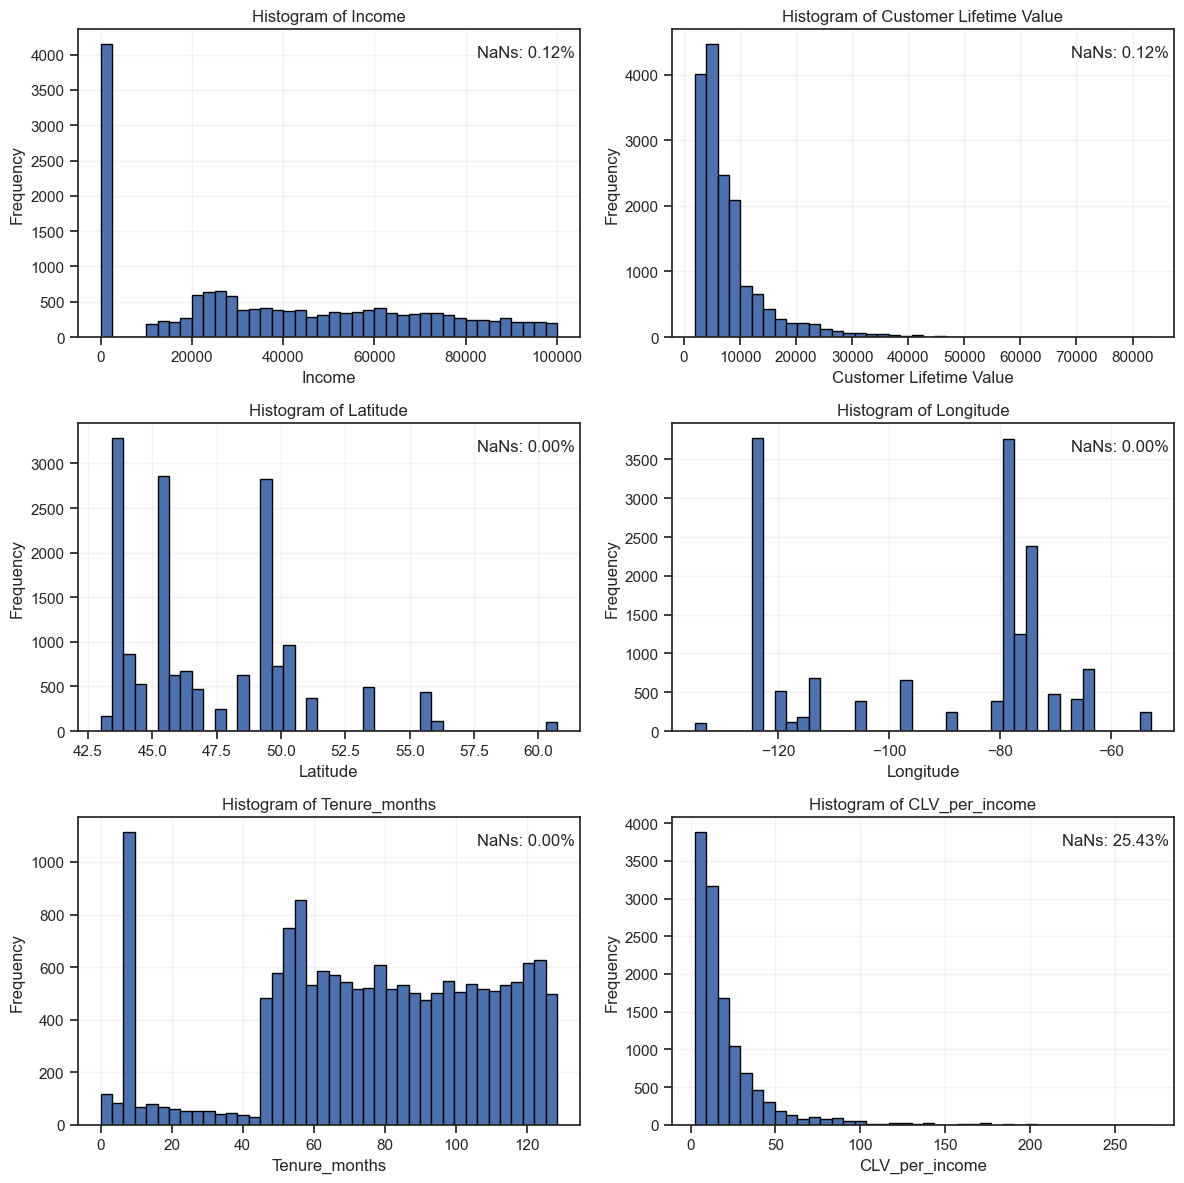

In [327]:
plot_histograms_side_by_side(customers_db, metric_features, bins=40)

**Income:** Two groups stand out: one at exactly 0, and another spread mostly between 15k and 100k. It is expected very different behaviors for the zero-income group vs. the positive-income bulk.

**Customer Lifetime Value:** Strongly right-skewed; most customers fall between ~2k–10k, the median sits in the mid-5k range, and a long, sparse tail stretches into high tens of thousands, indicating a small elite segment driving outsized value.

**Latitude:** Within Canadian bounds (~43°–61°N), with pronounced peaks near ~43–45° and ~49–50°, matching major population corridors (Southern ON/QC and BC).

**Longitude:** Distinct east/west clusters around ~−123 (BC coast) and ~−80 (ON/QC), plus lighter presence across the prairies; geography is strongly hub-concentrated.

**Tenure_months:** Most customers sit between 50 and 125 months (4–10 years), with a pronounced bump around 55–60 months, which is consistent with a large 2018–2019 enrollment cohort. There’s a small recent cohort in the 0–30 month range.

**CLV_per_income:** Highly right-skewed ratio; the bulk sits at low fractions (often <0.3), with a long tail of customers for whom captured value is large relative to income. 

##### 1.1.6.1.2. Non-Metric Features:

In [328]:
def plot_bar_chart_top15(
    df: pd.DataFrame,
    cols: list[str],
    ncols: int = 2,
    figsize_per_row: tuple = (12, 4),
    rotate_xticks: int = 30,
):

    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    total_rows = len(df)

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype("string")  
        counts = s.value_counts(dropna=False)    
        counts_plot = counts.iloc[:15]          

        categories = counts_plot.index.tolist()
        values = counts_plot.values

        ax.bar(categories, values, edgecolor="black")
        ax.set_title(f"{col} (Top-15)")
        ax.set_ylabel("Count")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")

        # Annotate percentage:
        for x, v in enumerate(values):
            pct = (v / total_rows * 100) if total_rows else 0
            ax.text(x, v, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

        # Annotate NaNs percentage:
        nan_pct = s.isna().mean() * 100
        ax.text(0.99, 0.95, f"NaNs: {nan_pct:.2f}%", transform=ax.transAxes, ha="right", va="top", fontsize=9)

    # Remove empty axis for odd number of variables:
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of tick

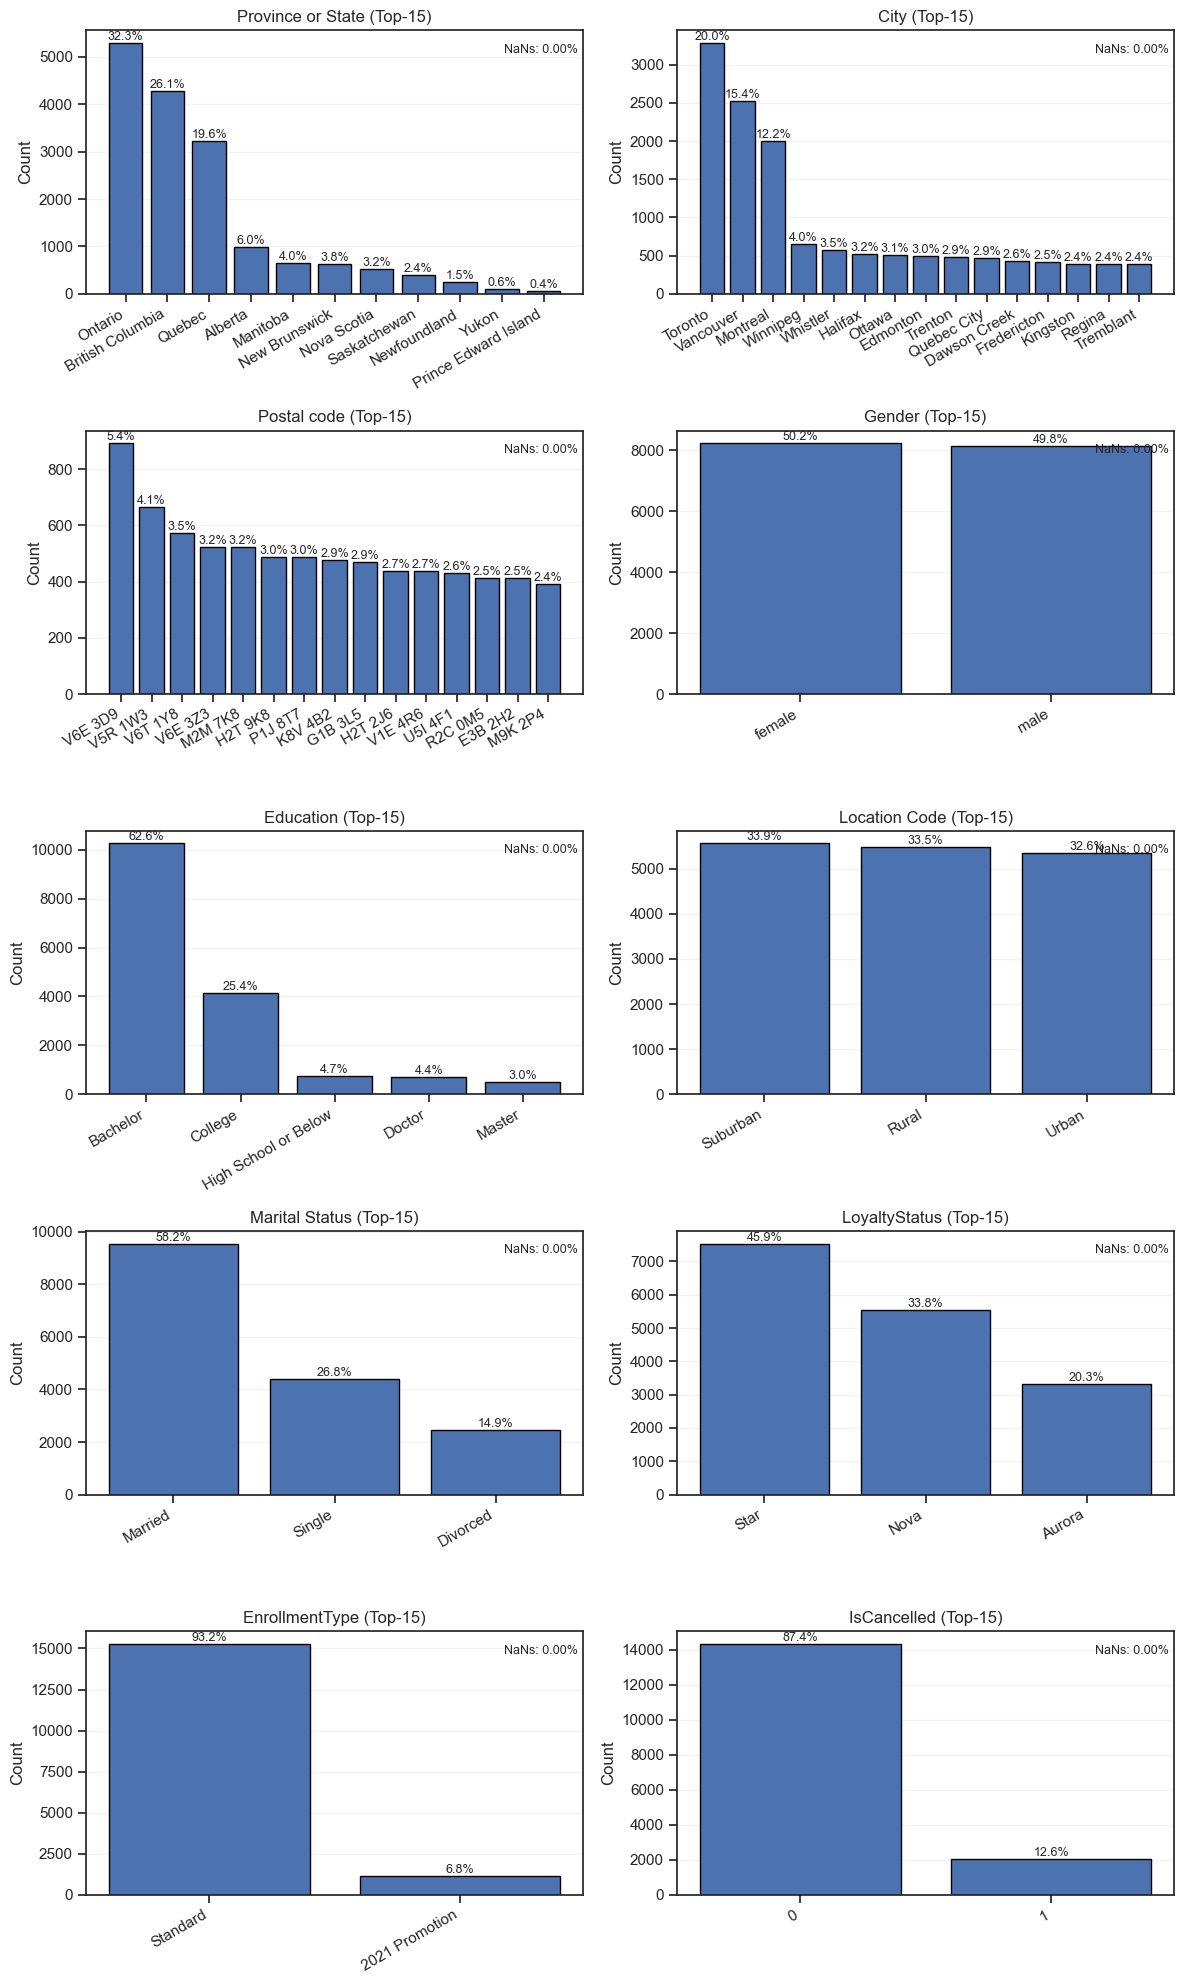

In [329]:
# Plot:
plot_bar_chart_top15(customers_db, non_metric_features, ncols=2, rotate_xticks=30)

**Province or State:** Highly concentrated in Ontario (~32%), followed by British Columbia (~26%) and Quebec (~20%); the rest of the provinces each contribute small shares.

**City:** Dominated by big hubs—Toronto (~20%), Vancouver (~15%), Montreal (~12%)—with a long tail of smaller cities each below ~4%.

**Postal code:** A few codes carry large shares (top code ~5.4%, next ~4.1%), indicating area-level coding rather than household-level granularity.

**Gender:** Essentially balanced, with female ~50.2% and male ~49.8%.

**Education:** Strong skew to Bachelor (~62.6%), then College (~25.3%); advanced degrees and “High School or Below” are small minorities.

**Location Code:** Fairly even split across Suburban (~33.8%), Rural (~33.5%), and Urban (~32.7%), with a slight suburban tilt.

**Marital Status:** Majority Married (~58%), with Single (~27%) and Divorced (~15%) making up the rest.

**LoyaltyStatus:** Tier mix leans to Star (~46%), then Nova (~34%), with Aurora (~20%) as the smallest tier.

**EnrollmentType:** Heavily dominated by Standard (~93%); 2021 Promotion (~7%) is a much smaller cohort.

**IsCancelled:** Vast majority active (~94.6%), with cancelled (~5.4%) representing a small minority

## Outliers:

In [330]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

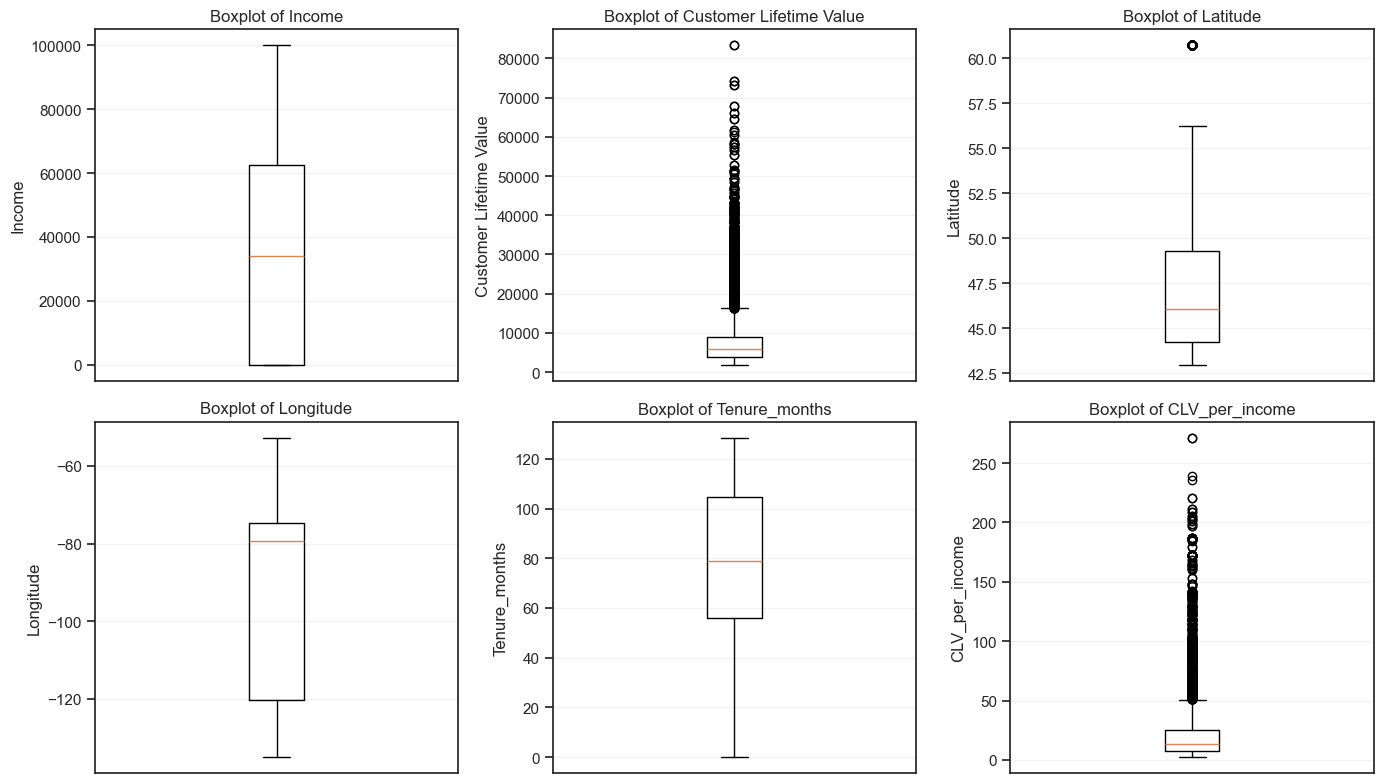

In [331]:
boxplot_grid(customers_db, metric_features, ncols=3, figsize=(14, 8), showfliers=True)

**Income:** 
- The boxplot shows a low median around 33–35k, with the lower quartile pressed near 0 and an IQR that stretches into the 60k range. Right-skew distribution. Whiskers extend far upward with many individual dots beyond, confirming a long upper tail up to ~100k.
- Outliers: Two types of outliers identified: 
    - A mass at 0 (could be true zero income or a placeholder) 
    - High earners in the 90th–99th percentiles. 

**Customer Lifetime Value:**
- The median is modest (~5–6k) and the IQR is relatively tight, but the whiskers are short compared to a dense cloud of high outliers reaching >80k. Strong right-skew distribution where a small fraction drives outsized value.
- Outliers: Top-percentile customers might be potential VIPs rather than errors.

**Latitude:**
- Center of the box lies in the mid-40s, with moderate spread; whiskers are short and only a few dots sit above ~61°N. Distribution is tight and plausible for Canada.
Outliers & actions: The high points likely reflect northern communities.

**Longitude:**
- Median sits near −80, with an IQR that spans from −120 to −75. Dots beyond whiskers toward −135 and −55 reflect west coast and Atlantic extremes. Shape is broad but geographically coherent.
- Outliers: Valid geographic spread. 

**Tenure_months:**
- Median around 80–85 months (~6–7 years) with a wide IQR into the 100+ months range, indicating many long-standing customers. The lower tail shows negative values and a small cluster just below zero (temporal inconsistencies).
- Outliers: Negative tenures are invalid.

**CLV_per_income:**
- Central tendency is low (~0.1–0.2), IQR is narrow, and there’s a pronounced right tail with ratios well >1. This tells us that most customers contribute modest value relative to income, while a minority show lower ratio.
- Outliers: Very high ratios often occur when income is tiny/zero or tenure is short. 

### Multivariate Analysis:

### Numerical x Numerical features:

In [332]:
def plot_pairwise_numeric(df, metric_features, title="Pairwise Relationship of Numerical Variables"):
    # Style and grid:
    sns.set_theme(style="ticks", rc={
        "axes.grid": True,
        "grid.color": ".9",
        "grid.linestyle": "-",
        "axes.spines.right": False,
        "axes.spines.top": False,
    })

    g = sns.pairplot(
        data=df[metric_features],
        diag_kind="hist",
        height=3.2,       
        aspect=1.0,
        corner=False,
        plot_kws=dict(
            s=14,         
            alpha=0.45,   
            linewidth=0.25,
            edgecolor="black",  
            rasterized=True     
        ),
        diag_kws=dict(
            bins=30,
            edgecolor="black",
            linewidth=0.2
        )
    )

    g.fig.suptitle(title, fontsize=18, y=1.02)
    plt.show()
    return g


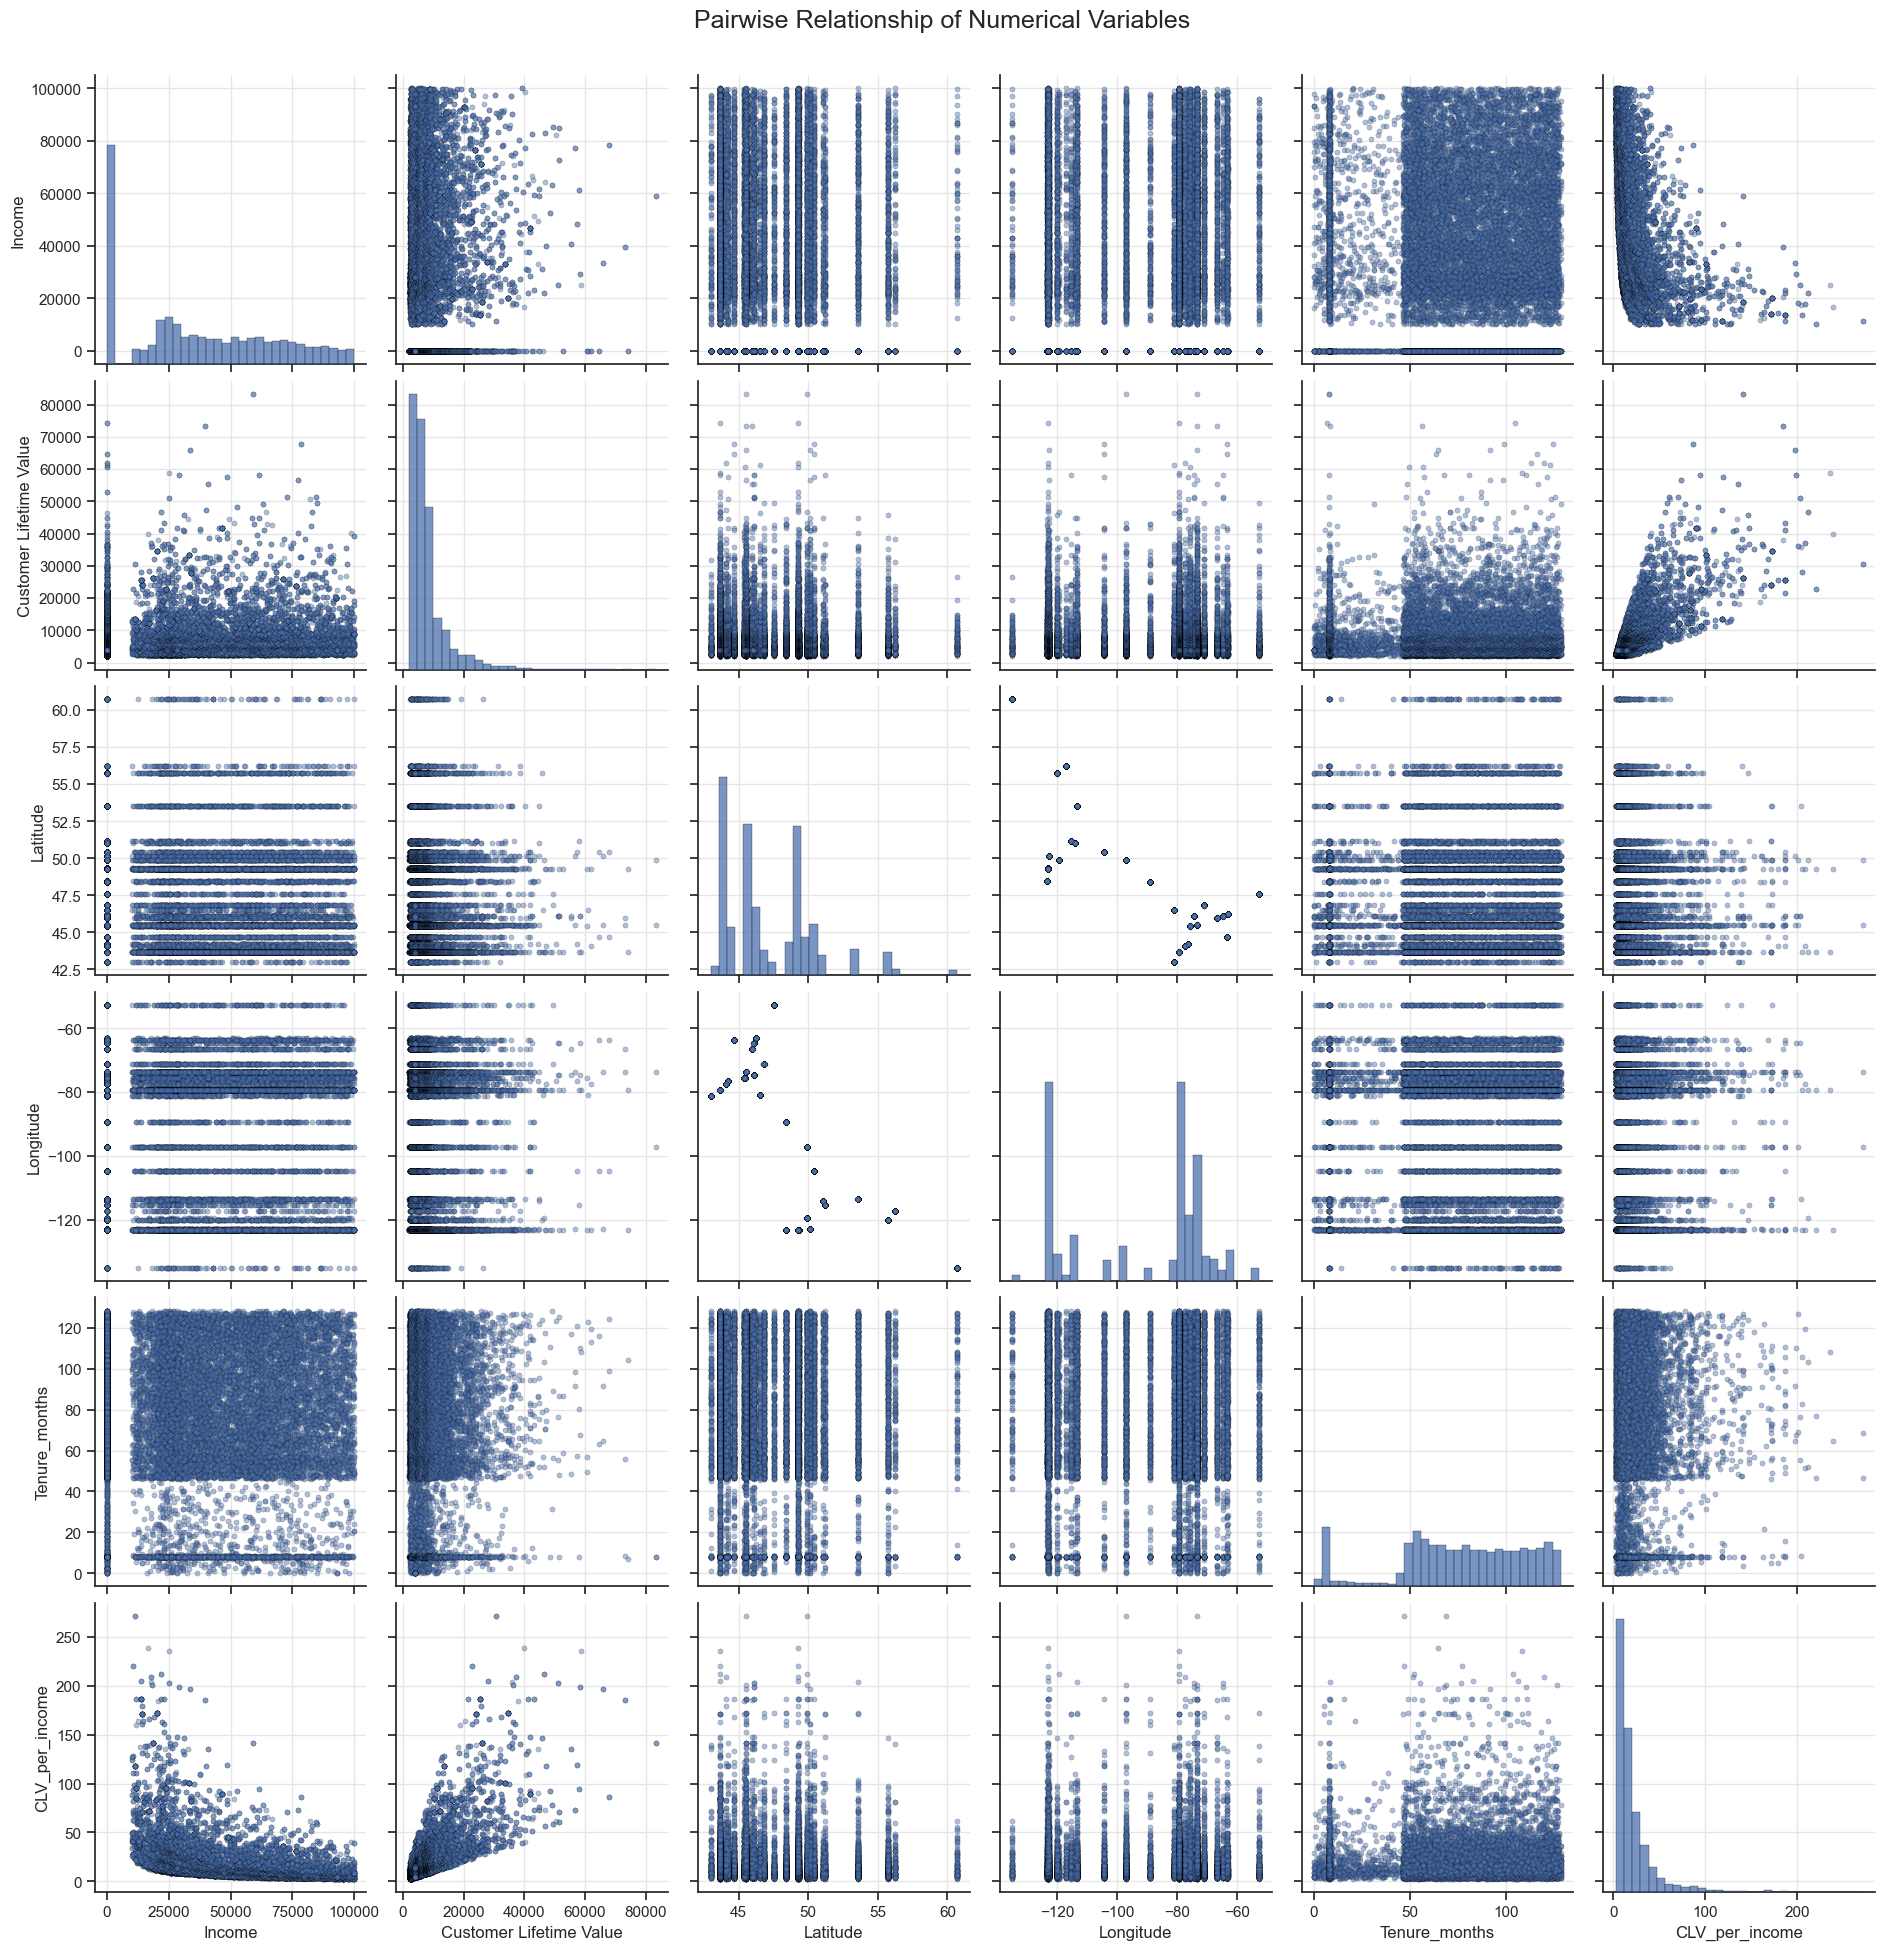

In [333]:
plot_pairwise_numeric(customers_db, metric_features)

**CLV vs Income:** Weak positive trend. High CLV occurs across the whole income range. Lots of spread, income alone does not order CLV well.

**CLV vs Tenure_months:** Non-linear pattern. CLV rises quickly for early tenure and seems to plateau; broad vertical spread at any given tenure (cohort effect).

**Income vs Tenure_months:** No monotonic relationship. The tenure band 50–125m has income spread wide, plus the vertical line at Income=0.

**CLV_per_income vs Tenure_months:** Most ratios remain low across tenure with a few high spikes tied to low income.

### Hexbin matrix:

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/2124452425.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


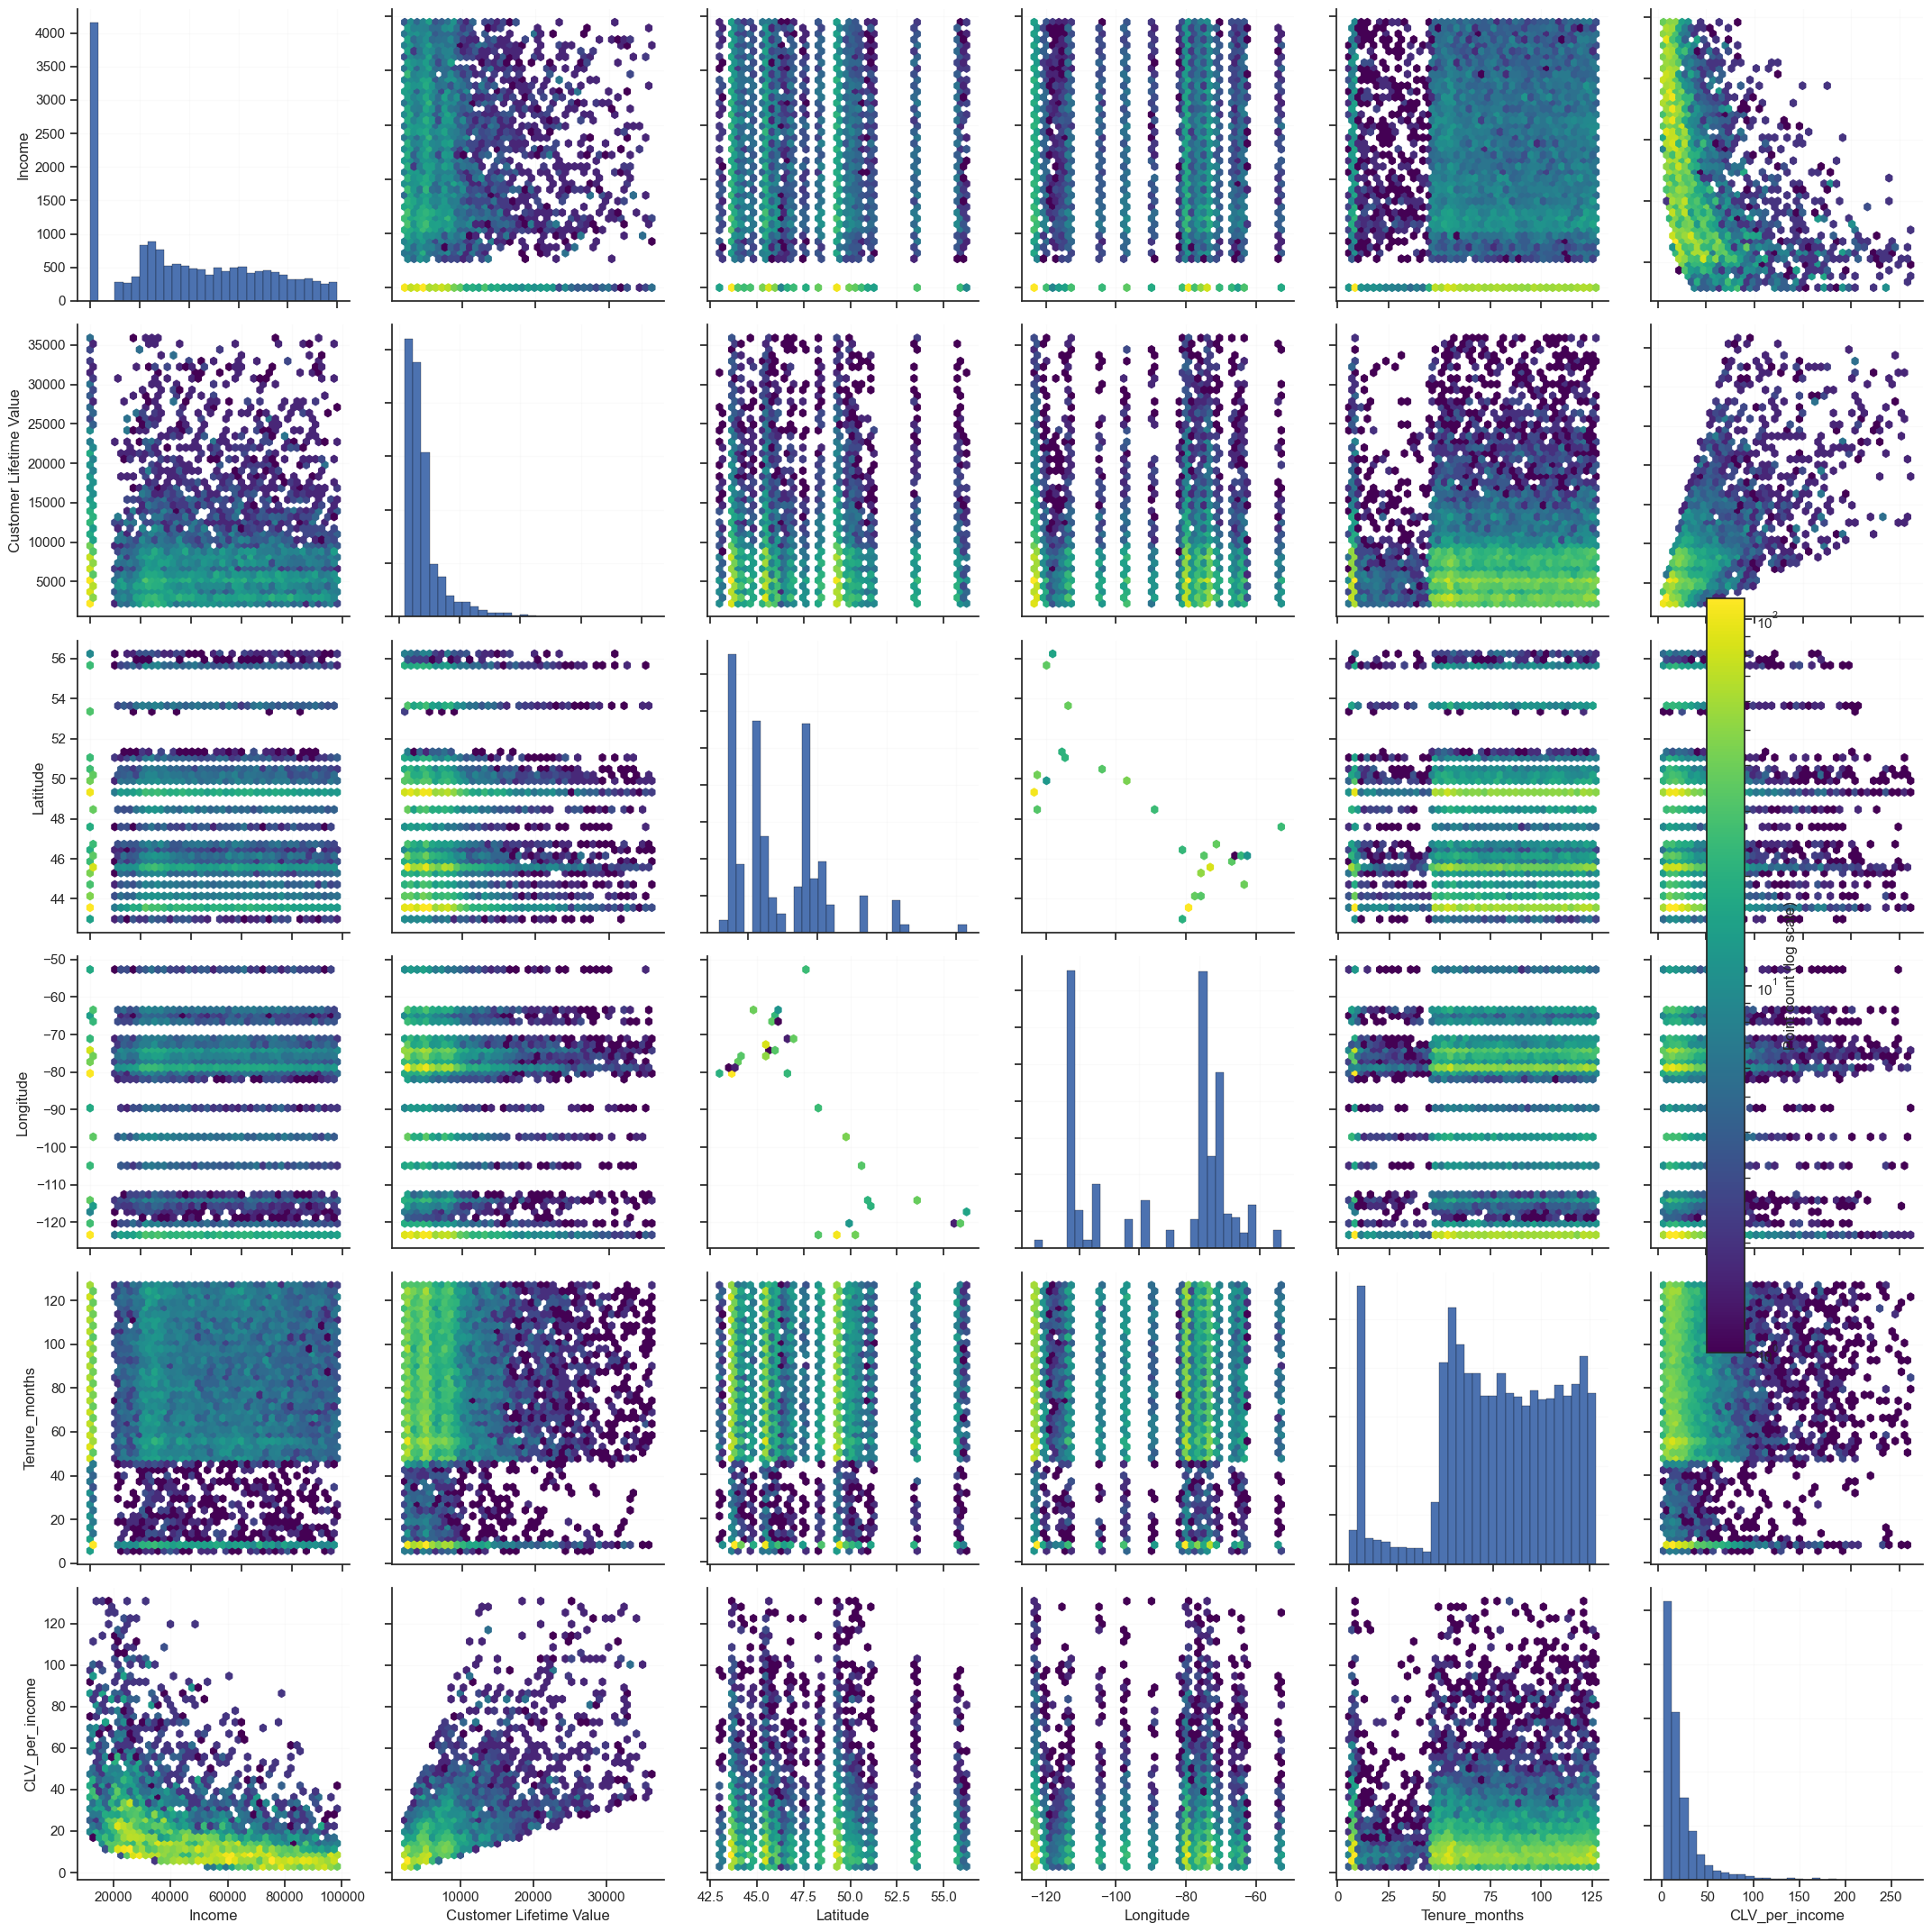

In [334]:
def hexbin_matrix(
    df: pd.DataFrame,
    cols: list[str],
    gridsize: int = 40,           # hex resolution
    clip_q: tuple[float, float] = (0.01, 0.99),  # percentile limits per axis
    log_counts: bool = True,      # log color scale for dense plots
    cmap: str = "viridis",
    mincnt: int = 1               # hide hexes with < mincnt points
):
    n = len(cols)
    fig, axes = plt.subplots(n, n, figsize=(3.6*n, 3.6*n))
    axes = np.atleast_2d(axes)

    last_hb = None  # keep a handle for a shared colorbar

    for i, ycol in enumerate(cols):
        for j, xcol in enumerate(cols):
            ax = axes[i, j]

            if i == j:
                # Diagonal: histogram of each feature
                s = df[xcol].dropna().astype(float)
                ax.hist(s, bins=30, edgecolor="black", linewidth=0.2)
                ax.set_ylabel("")
                ax.set_xlabel("")
                ax.grid(alpha=0.2)
            else:
                # Off-diagonal: hexbin for the pair
                x = df[xcol].astype(float).to_numpy()
                y = df[ycol].astype(float).to_numpy()
                mask = np.isfinite(x) & np.isfinite(y)
                x, y = x[mask], y[mask]

                # Percentile clipping for visibility
                if clip_q is not None and len(x) and len(y):
                    x1, x2 = np.quantile(x, clip_q)
                    y1, y2 = np.quantile(y, clip_q)
                    extent = [x1, x2, y1, y2]
                else:
                    extent = None

                hb = ax.hexbin(
                    x, y,
                    gridsize=gridsize,
                    mincnt=mincnt,
                    cmap=cmap,
                    bins="log" if log_counts else None,
                    extent=extent
                )
                last_hb = hb
                ax.grid(alpha=0.2)

            # Axis labels only on outer edges
            if i == n-1:
                ax.set_xlabel(cols[j])
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(cols[i])
            else:
                ax.set_yticklabels([])

    # Shared colorbar
    if last_hb is not None:
        label = "Point count (log scale)" if log_counts else "Point count"
        cbar = fig.colorbar(last_hb, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
        cbar.set_label(label)

    plt.tight_layout()
    plt.show()


hexbin_matrix(customers_db, metric_features, gridsize=40, clip_q=(0.01, 0.99), log_counts=True)


### Correlation matrix:

#### Spearman:

Handles skewness and outliers better than Pearson:

In [335]:
def plot_corr_heatmap(df, metric_features):
    
    fig = plt.figure(figsize=(10, 8)) 
    corr = df[metric_features].corr(method="spearman")
    sns.heatmap(data=corr, annot=True, )

    plt.show()

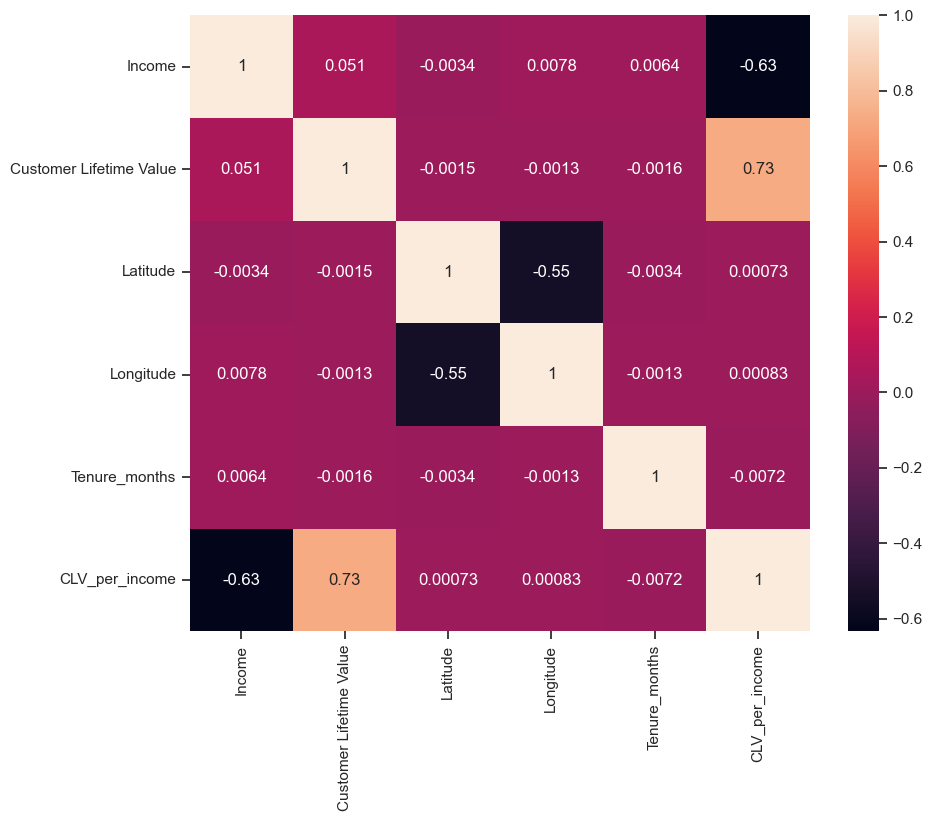

In [336]:
plot_corr_heatmap(customers_db, metric_features)

**CLV_per_income and CLV, Income**:
- Strong positive correlation, as expected. Redundant features. 

**Geography - Latitude, Longitude: −0.55 (moderate negative correlation):**
- Canada’s populated band runs SW–NE; as longitude increases (less negative, moving east), latitude generally decreases a bit—hence a negative monotonic relation.

**Near-zero relationships:**
- CLV, Income: +0.056 (very weak)
    - Customer value is only weakly ordered by declared income. High-CLV customers exist across income levels. Income alone isn’t a strong driver of value.

- Tenure_months with CLV (+0.003), Income (+0.004), CLV_per_income (−0.005): ~0:
    - Little monotonic pattern overall.

- Latitude/Longitude with CLV/Income: ~0
    - No clear rank trend between value/income and raw coordinates.

### Categorical x Categorical features:

In [337]:
def plot_stacked_bars_grid(
    df,
    features,                    
    stack_by="IsCancelled",      
    ncols=2,
    top_n=12,                    
    normalize=True,             
    figsize_per_row=(12, 4),
    rotate_xticks=30
):
    # figure grid
    n = len(features)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1]*nrows))
    axes = np.atleast_1d(axes).ravel()

    # stack order - sorted by frequency
    stack_levels = df[stack_by].astype("string").value_counts(dropna=False).index.tolist()

    for i, col in enumerate(features):
        ax = axes[i]
        s = df[col].astype("string").str.strip()

        # Keep top-N categories + 'Other'
        vc = s.value_counts(dropna=False)
        if top_n and len(vc) > top_n:
            top_vals = set(vc.head(top_n).index)
            s = s.where(s.isin(top_vals), "Other")

        # crosstab
        ct = pd.crosstab(s, df[stack_by].astype("string"), dropna=False).reindex(columns=stack_levels, fill_value=0)
        ct = ct.sort_values(ct.columns.tolist(), ascending=False)

        # normalize to percentages:
        if normalize:
            pct = ct.div(ct.sum(axis=1), axis=0).fillna(0) * 100
            plot_df = pct
            ylabel = "Percent"
        else:
            plot_df = ct
            ylabel = "Count"

        # plot stacked bars
        bottoms = np.zeros(len(plot_df))
        x = np.arange(len(plot_df.index))
        for lvl in plot_df.columns:
            vals = plot_df[lvl].values
            ax.bar(x, vals, bottom=bottoms, label=str(lvl))
            bottoms += vals

        # labels:
        ax.set_title(f"{col} × {stack_by}")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df.index, rotation=rotate_xticks, ha="right")
        ax.grid(axis="y", alpha=0.25)

        # annotate percentages on the bars:
        if normalize:
            for xi in x:
                y0 = 0
                for lvl in plot_df.columns:
                    v = plot_df.loc[plot_df.index[xi], lvl]
                    if v >= 5:  
                        ax.text(xi, y0 + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=8)
                    y0 += v

    # legend:
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=stack_by, loc="upper center", ncol=min(len(labels), 5), frameon=False, bbox_to_anchor=(0.5, 1.02))

    # remove unused axes:
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



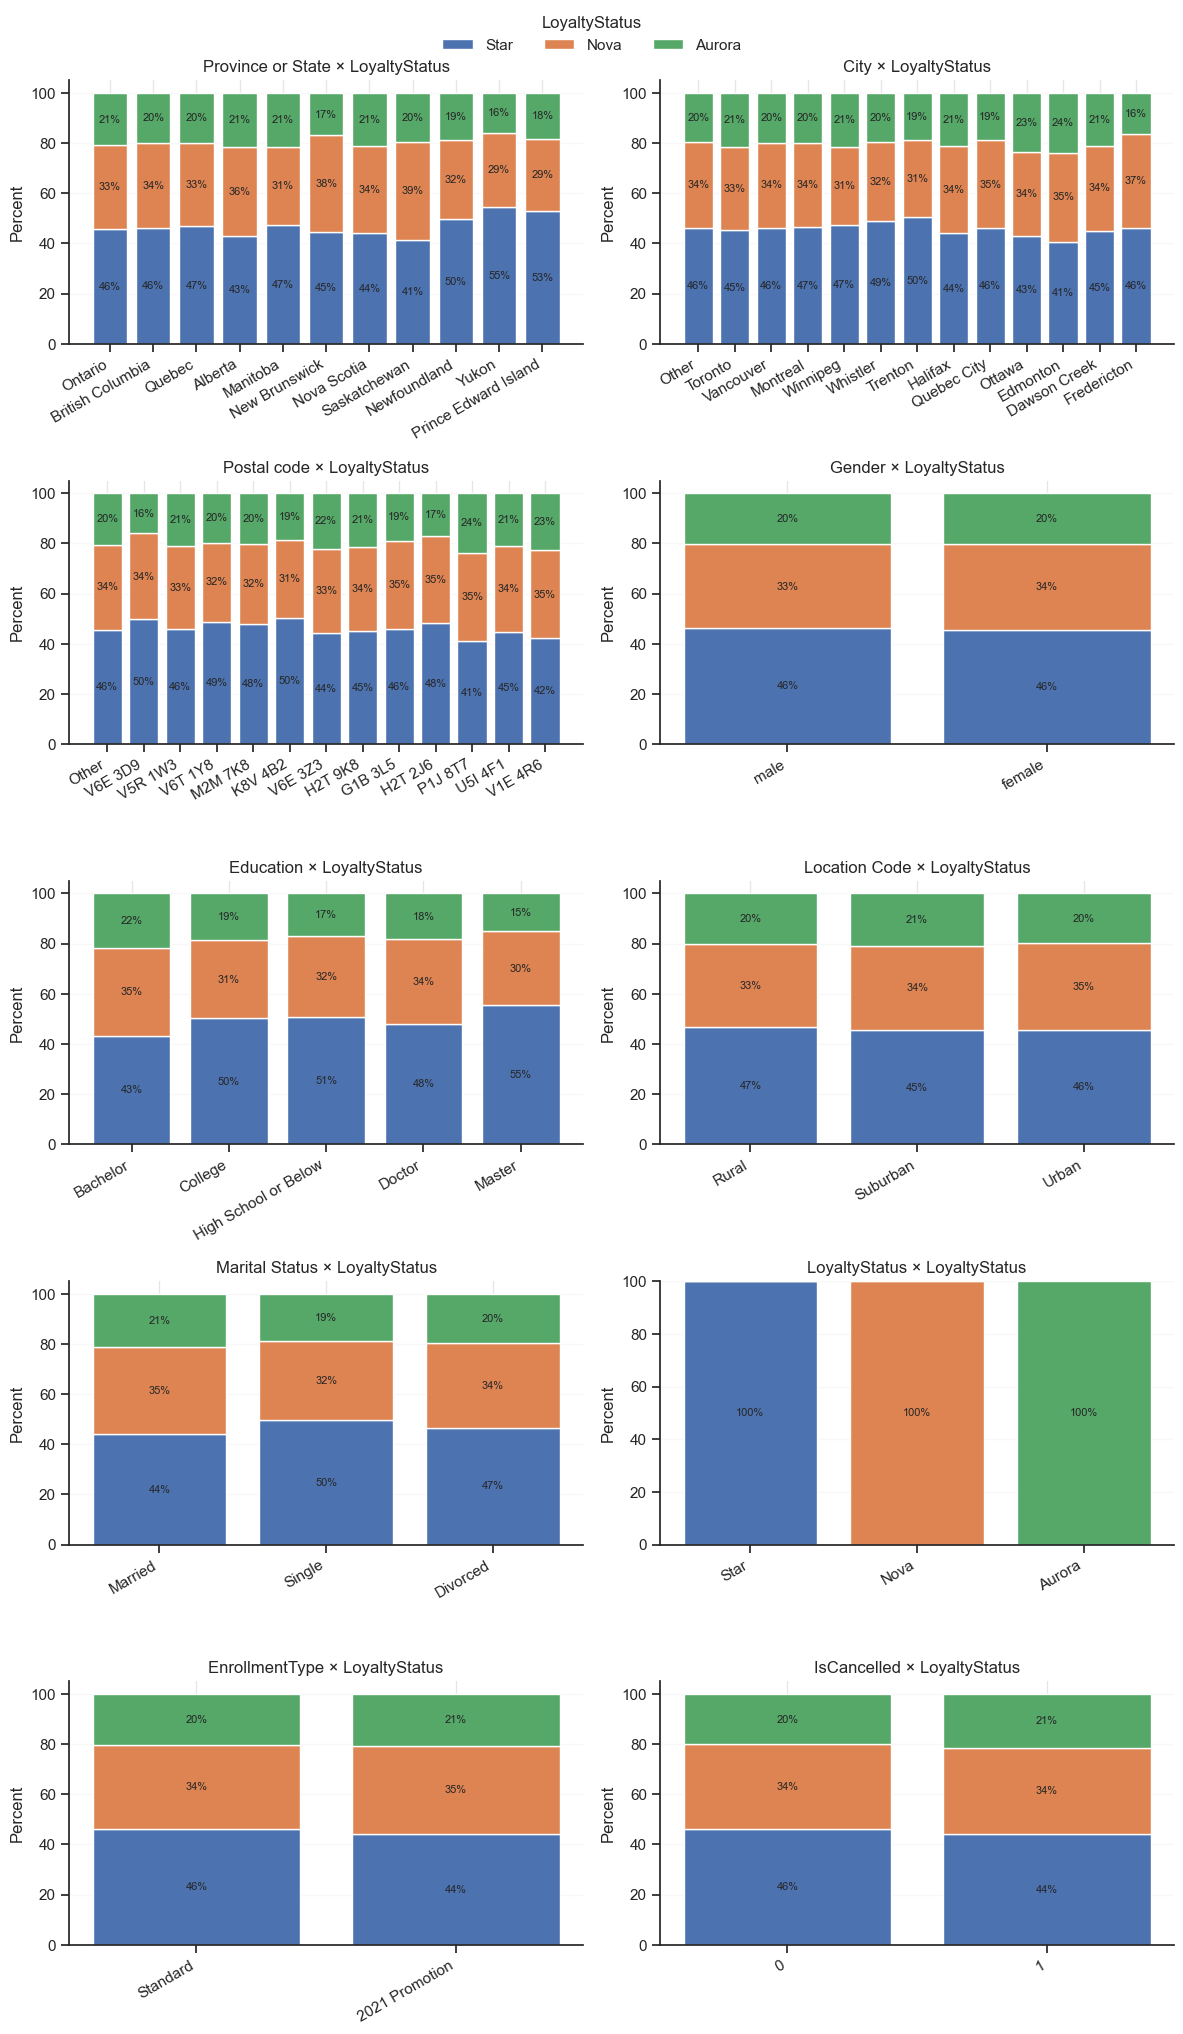

In [338]:
plot_stacked_bars_grid(
    customers_db,
    features=non_metric_features,
    stack_by="LoyaltyStatus",   
    ncols=2,
    top_n=12,                 
    normalize=True
)

**We can conclude that LoyaltyStatus (Star, Nova, Aurora) does not vary significantly across segments.**

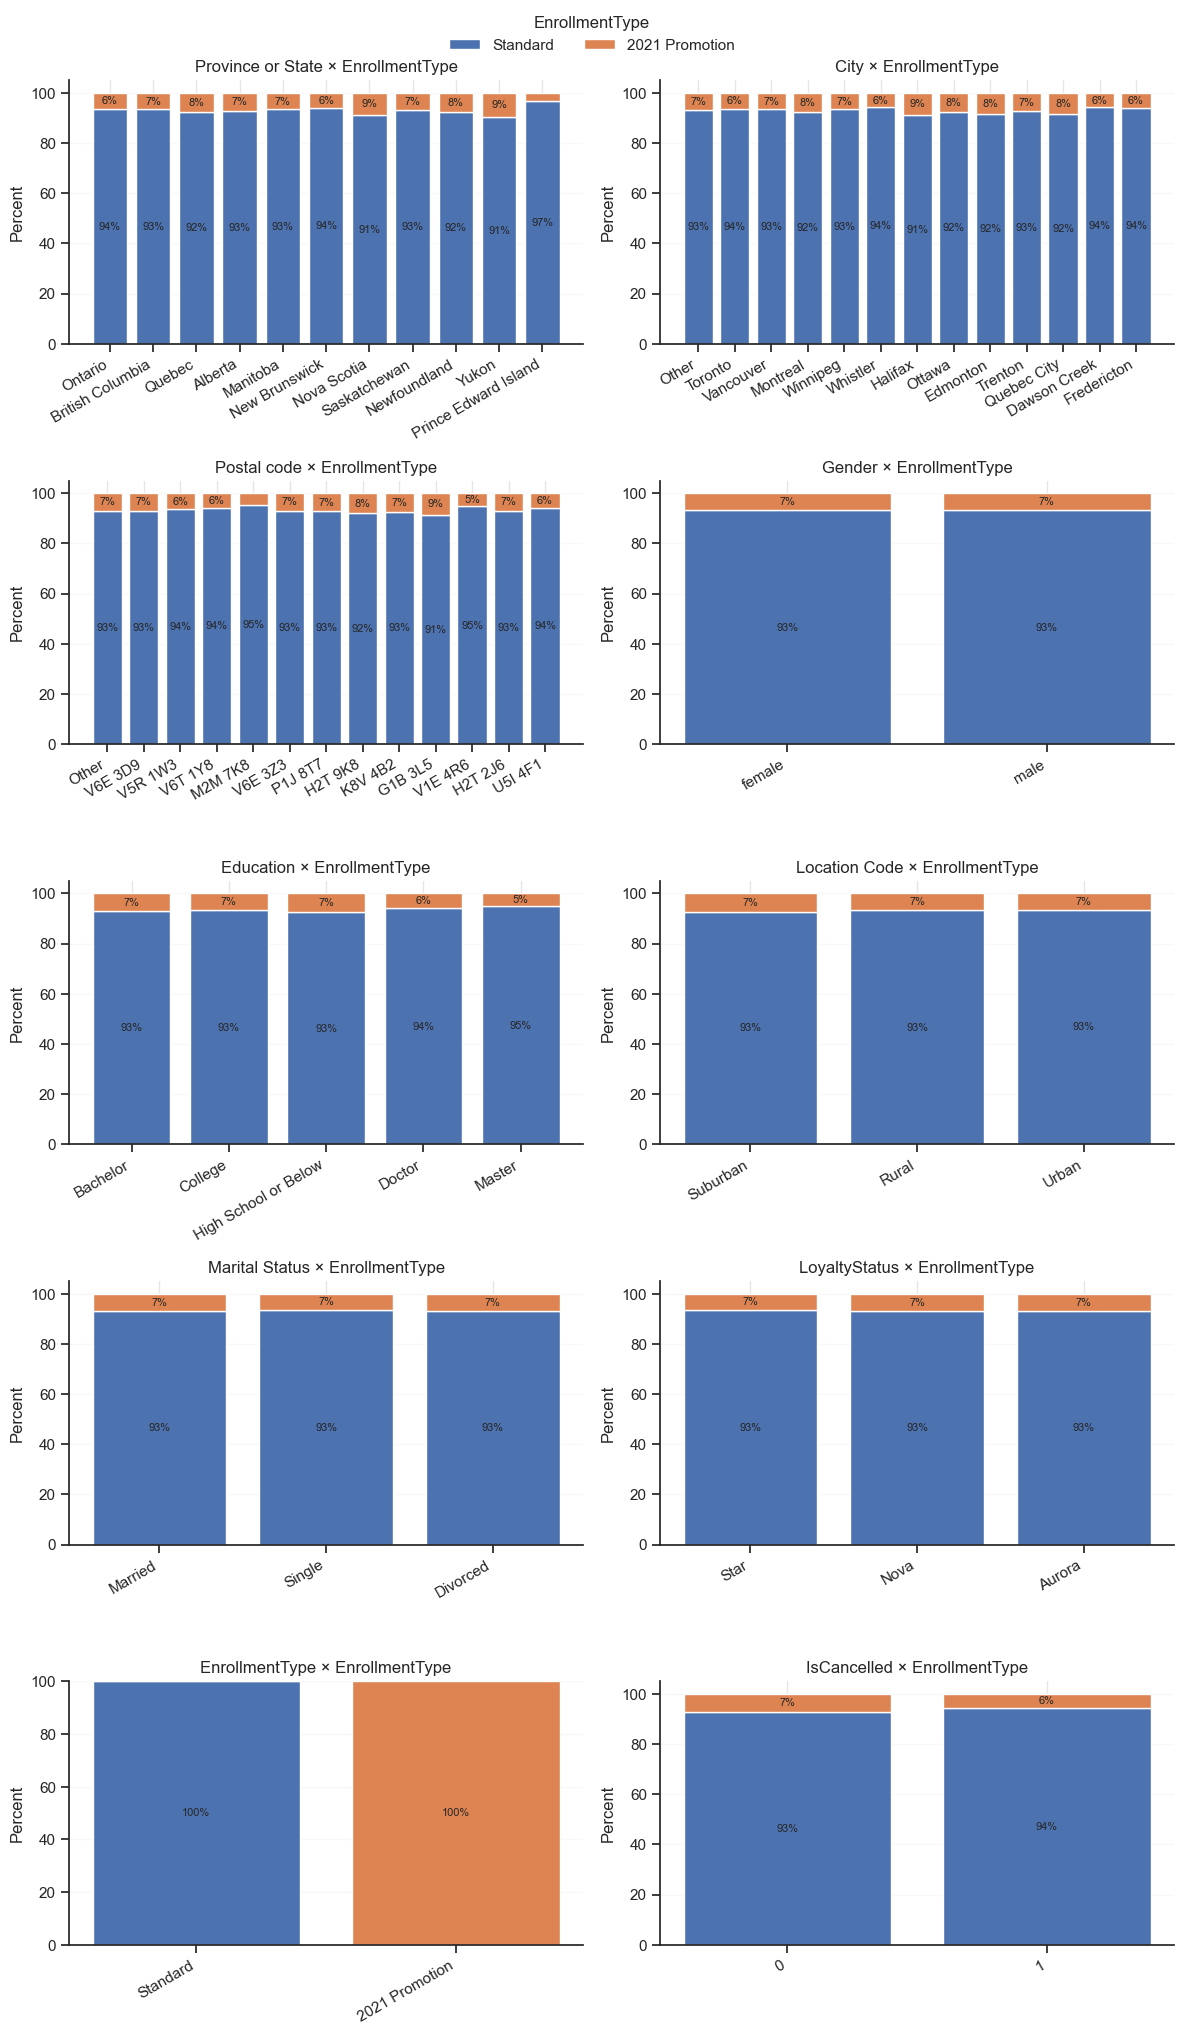

In [339]:
plot_stacked_bars_grid(
    customers_db,
    features=non_metric_features,
    stack_by="EnrollmentType",   
    ncols=2,
    top_n=12,                 
    normalize=True
)

**We can conclude that EnrollmentType (Standard vs 2021 Promotion) does not vary across segments.**

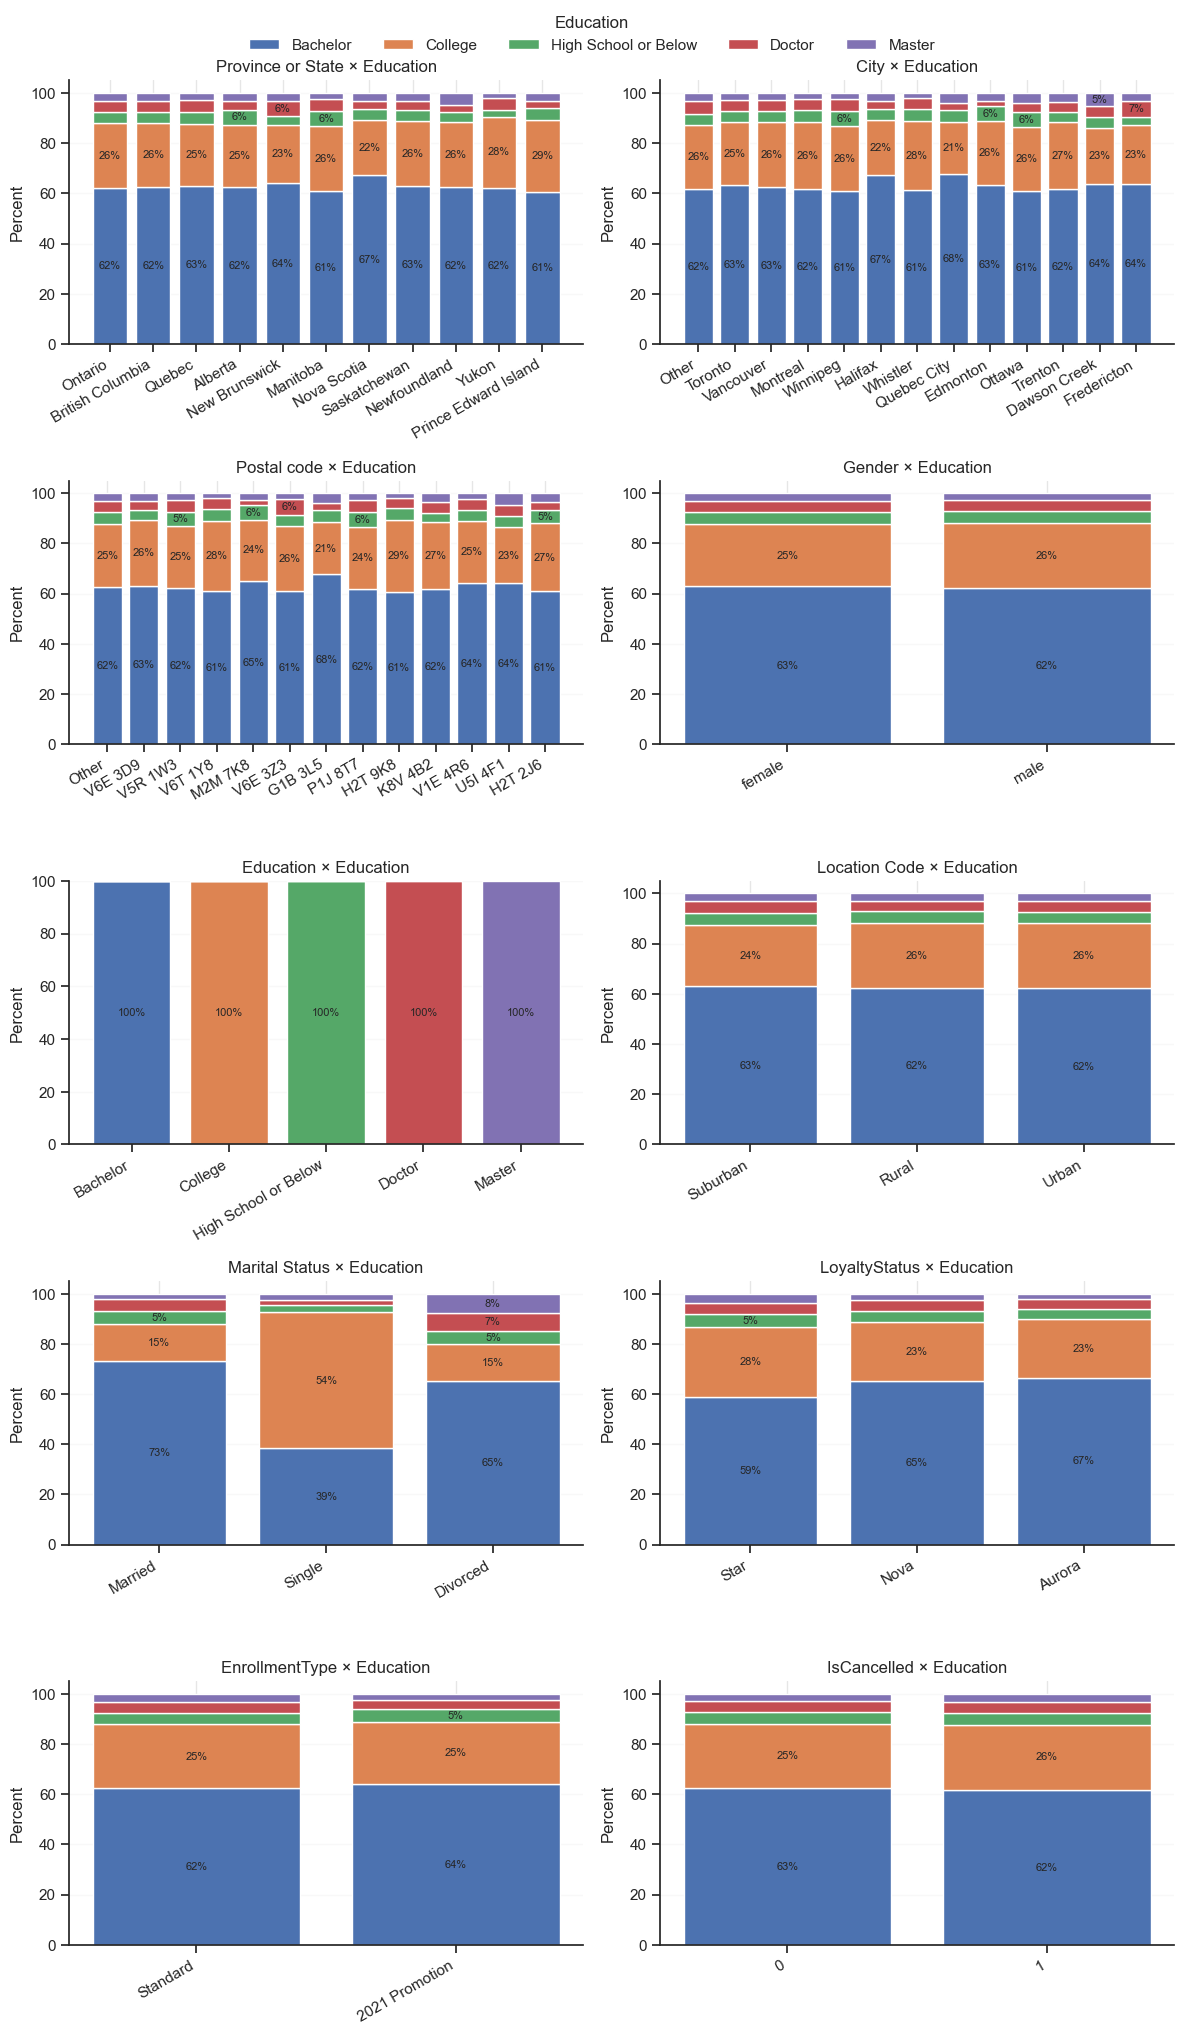

In [340]:
plot_stacked_bars_grid(
    customers_db,
    features=non_metric_features,
    stack_by="Education",   
    ncols=2,
    top_n=12,                 
    normalize=True
)

**Education x MaritalStatus:**
- Marital status is associated with education mix: Single leans College (~54%) with lower Bachelor (~38%). Married has higher Bachelor (~73%); Divorced sits between (~65% Bachelor). 

**We can conclude that, apart from marital status, Education does not vary significantly across segments.**

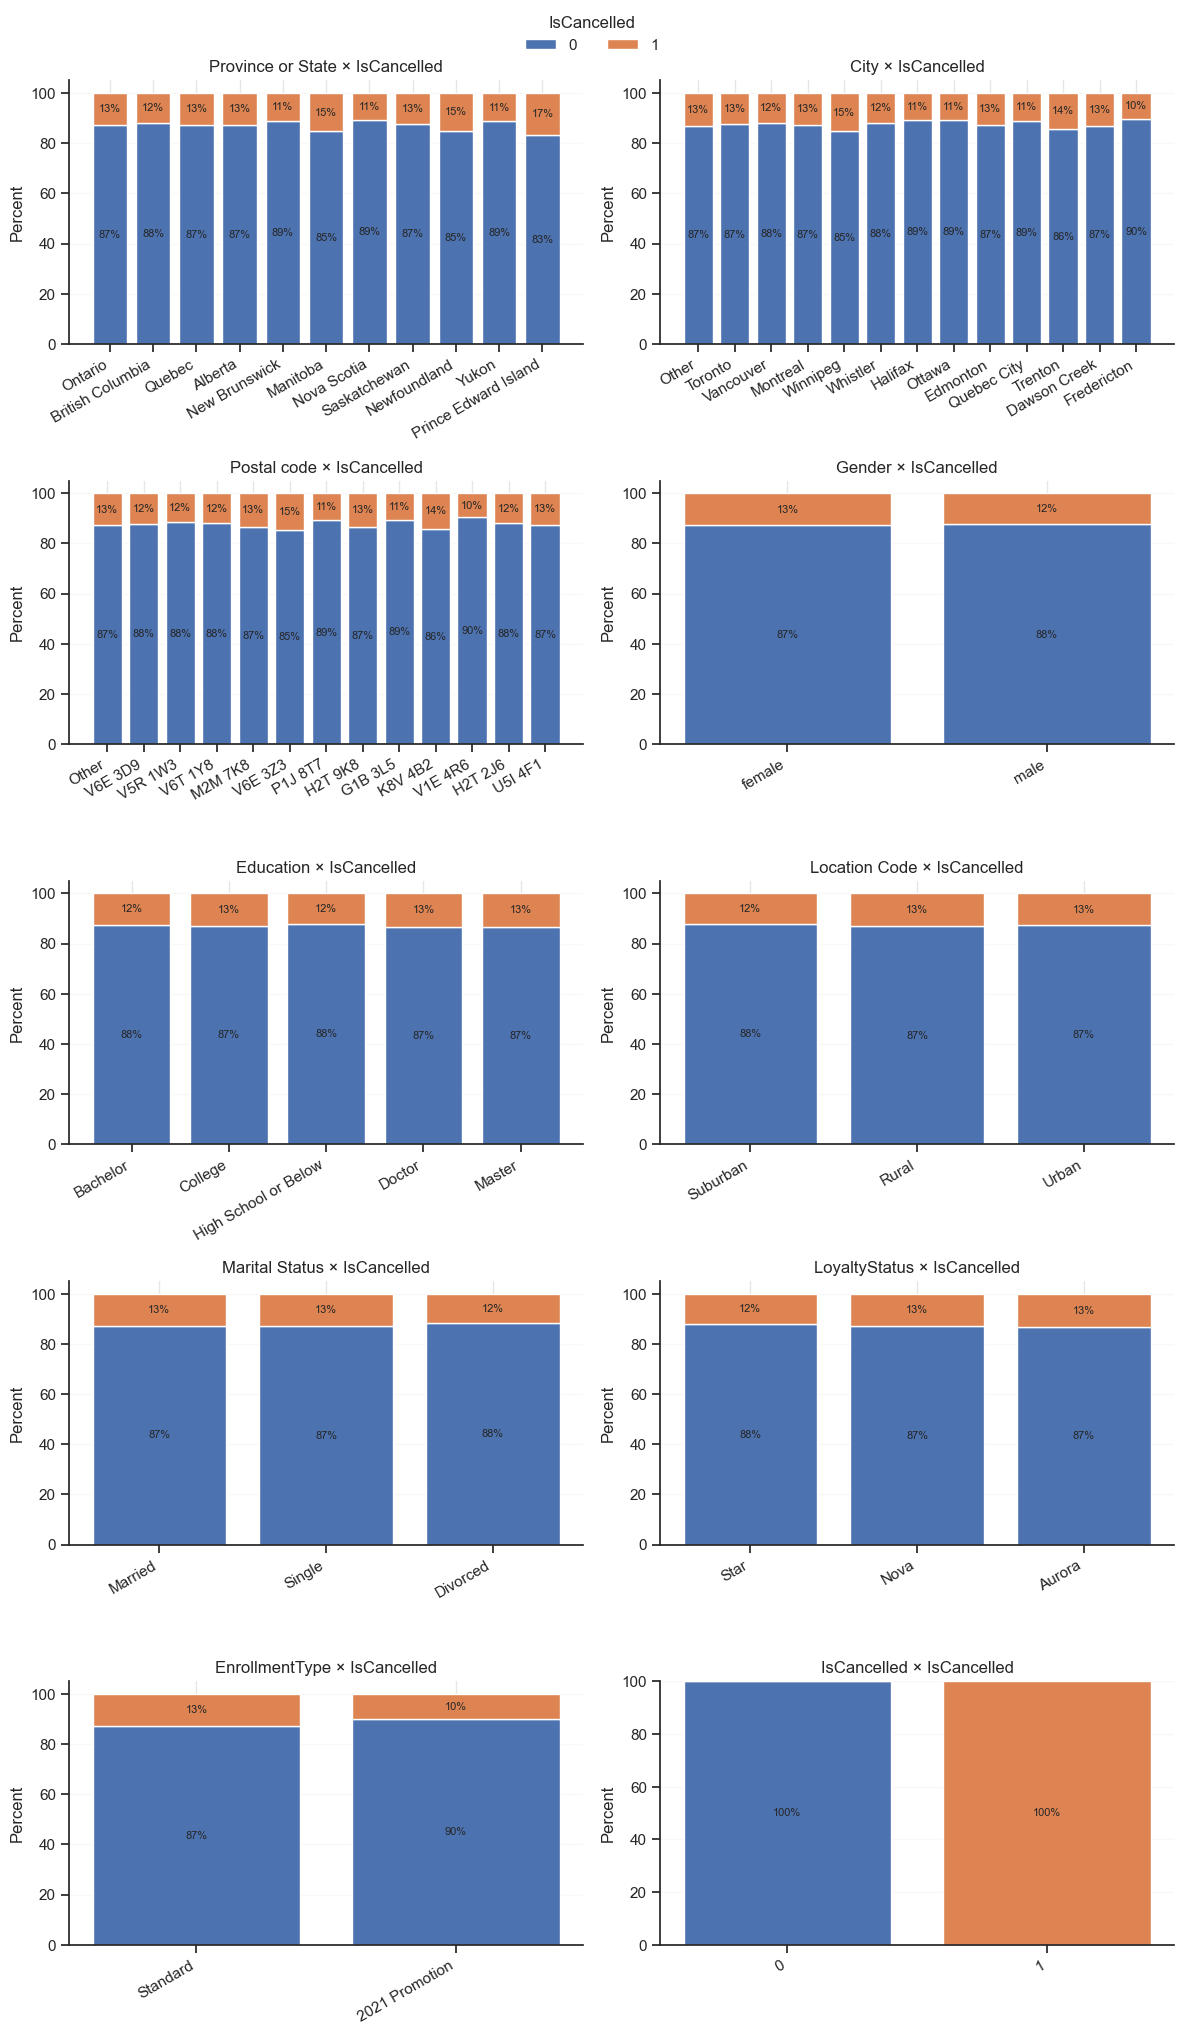

In [341]:
plot_stacked_bars_grid(
    customers_db,
    features=non_metric_features,
    stack_by="IsCancelled",   
    ncols=2,
    top_n=12,                 
    normalize=True
)

**We can conclude that cancellation rate does not vary across segments.**

### Numerical x Categorical features:

In [342]:
def plot_hist_by_categories(
    df,
    numeric_col: str,
    cat_cols: list[str],
    ncols: int = 2,
    bins: int | str = 40,         
    stat: str = "density",        
    element: str = "step",         
    alpha: float = 0.35,
    figsize_per_row: tuple = (12, 4),
    title_prefix: str = "Histogram of",
):

    sns.set_theme(style="ticks")

    # Compute common bins from the numeric column (ignores NaNs)
    x = df[numeric_col].astype(float)
    bin_edges = np.histogram_bin_edges(x[np.isfinite(x)], bins=bins)

    n = len(cat_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, cat in enumerate(cat_cols):
        ax = axes[i]
        sns.histplot(
            data=df.dropna(subset=[cat]),
            x=numeric_col,
            hue=cat,
            bins=bin_edges,
            element=element,
            stat=stat,
            common_bins=True,
            alpha=alpha,
            ax=ax,
        )
        ax.set_title(f"{title_prefix} {numeric_col} by {cat}")
        ax.grid(alpha=0.25)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    plt.show()


#### Customer Lifetime Value by category:

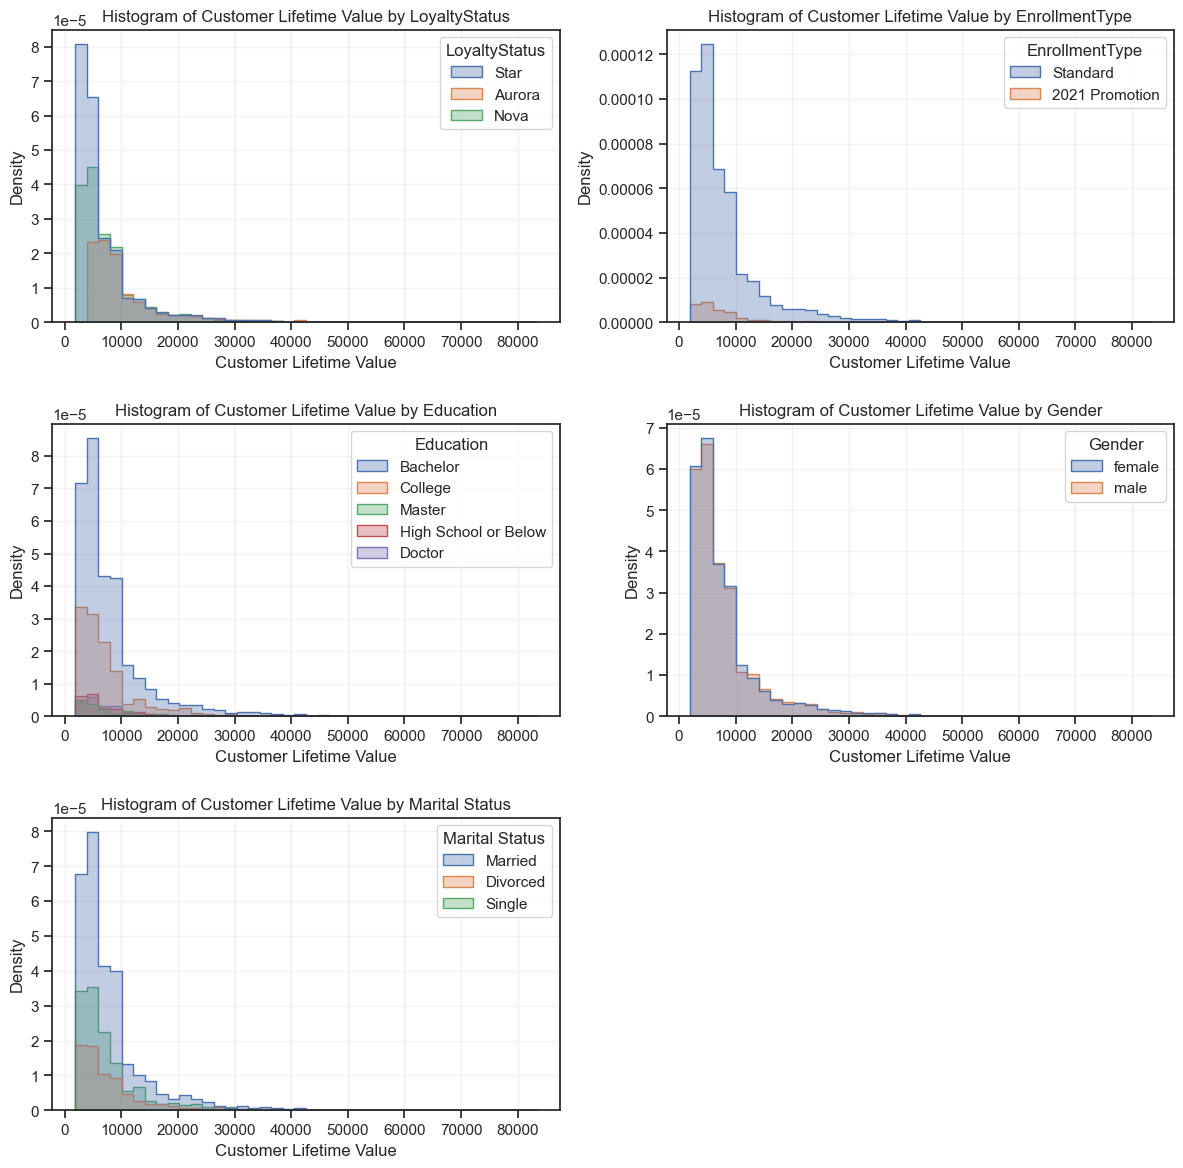

In [343]:
plot_hist_by_categories(
    customers_db,
     numeric_col="Customer Lifetime Value",
   cat_cols=["LoyaltyStatus", "EnrollmentType", "Education", "Gender", "Marital Status"],
    ncols=2,
    bins=40,
 )

**Across every category, CLV is heavily right-skewed with a long high-value tail; category curves mostly overlap, indicating weak marginal differences. The only consistent deviation is EnrollmentType, where the 2021 promo looks slightly lower, but that is likely confounded by tenure.**

#### Tenure by category:

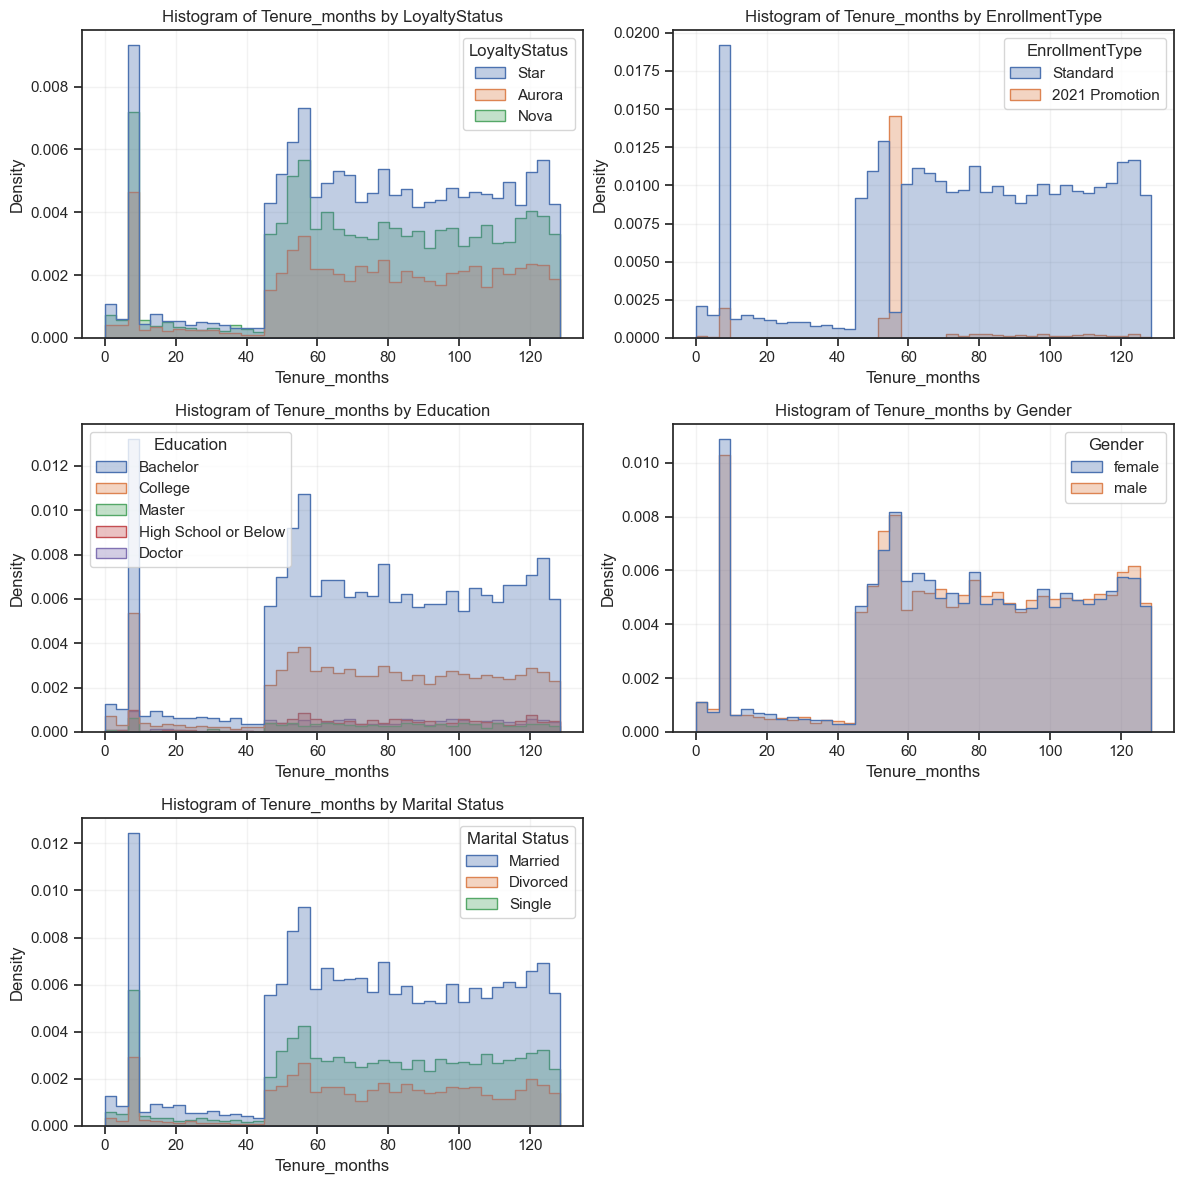

In [344]:
plot_hist_by_categories(
    customers_db,
     numeric_col="Tenure_months",
   cat_cols=["LoyaltyStatus", "EnrollmentType", "Education", "Gender", "Marital Status"],
    ncols=2,
    bins=40,
 )

- **The program is mature: most customers have 4–10+ years of tenure (~50–125 months).**
- **Across every category, tenure_months distribution is very similar; category curves mostly overlap, indicating weak marginal differences. The only consistent deviation is EnrollmentType, where the Standard cohort spans broadly ~50–125m and the 2021 Promotion line is a thin ridge concentrated near the ~55–70m band and much smaller everywhere else, which is consistent with a recent, small cohort.**

#### Income by category:

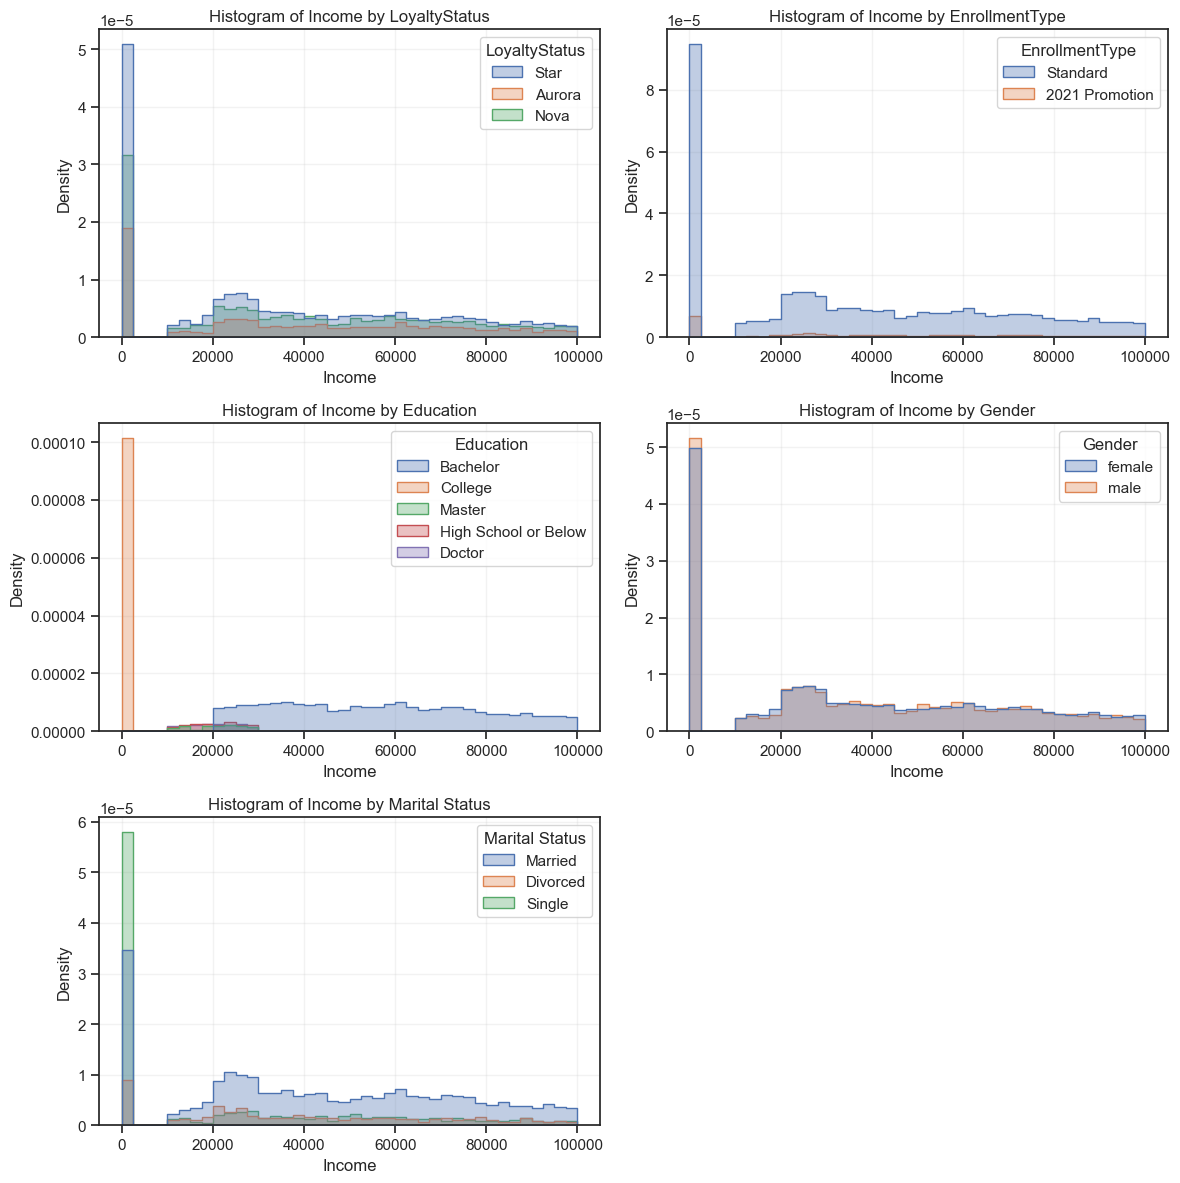

In [345]:
plot_hist_by_categories(
    customers_db,
     numeric_col="Income",
   cat_cols=["LoyaltyStatus", "EnrollmentType", "Education", "Gender", "Marital Status"],
    ncols=2,
    bins=40,
 )

- **Income has a bimodal distribution with a very large spike at 0, plus a broad right-skewed positive distribution up to ~100k.**

- **Income is not segmented by LoyaltyStatus, EnrollmentType, or Gender since across these categories, income distribution is very similar and category curves mostly overlap.**

- **The income spike at 0 is dominated by College students, consistent with students reporting no income. Among positive incomes,there is heavy overlap: Bachelor has the broadest mass across 25k–80k; High-School or Below concentrates lower (≈15k–40k).**

- **There are modest differences by Education and by Marital Status, but the overlap is substantial so the effect size is likely small to moderate.**

In [346]:
combined_flights_data_per_loyalty_no = flights_db.groupby('Loyalty#').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',
    'DollarCostPointsRedeemed': 'sum'
}).reset_index()
combined_flights_data_per_loyalty_no

customer_flights_combined = pd.merge(customers_db, combined_flights_data_per_loyalty_no, on='Loyalty#', how='left')
customer_flights_combined

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,Tenure_months,IncomeZero_flag,IncomeNA_flag,CLV_per_income,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,81.3,0,0,5.473070,189.6,56.1,507054.9,50699.39,13517.9,134.6
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,80.5,1,0,NaN,279.1,32.2,426827.4,42672.54,22457.8,221.4
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,42.5,1,0,NaN,120.0,39.9,238376.1,23832.41,5479.6,53.2
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,117.7,1,0,NaN,195.9,58.5,386029.3,38595.63,16331.5,162.2
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,97.2,0,0,3.927948,170.7,62.9,369242.6,36916.56,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16390,100012,Ethan Thompson,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,...,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16391,100013,Layla Young,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,...,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16392,100014,Amelia Bennett,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,...,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16393,100015,Benjamin Wilson,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,...,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [348]:
customers_filled_with_median = customers_db.copy()

#BEst way?
# Income median should be calculated accodring to the factors affecting it. Rather than median of full income?
customers_filled_with_median['Income'] = customers_filled_with_median['Income'].fillna(customers_filled_with_median['Income'].median())
customers_filled_with_median['Customer Lifetime Value'] = customers_filled_with_median['Customer Lifetime Value'].fillna(customers_filled_with_median['Customer Lifetime Value'].median())

In [349]:
customers_filled_with_median['IsActive'] = customers_filled_with_median['CancellationDate'].isna()
customers_filled_with_median['EffectiveEndDate'] = customers_filled_with_median['CancellationDate'].fillna(today)
customers_filled_with_median['TenureDays'] = (
    customers_filled_with_median['EffectiveEndDate'] - customers_filled_with_median['EnrollmentDateOpening']
).dt.days
customers_filled_with_median.drop('CancellationDate', axis=1, inplace=True)

sorted_customers_filled_with_median = customers_filled_with_median.sort_values(by='Loyalty#')

customer_flights_combined_filled = pd.merge(
    customers_filled_with_median,
    combined_flights_data_per_loyalty_no,
    on='Loyalty#',
    how='left'
)

customer_flights_combined_filled

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,CLV_per_income,IsActive,EffectiveEndDate,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,5.473070,True,2025-10-19,2438,189.6,56.1,507054.9,50699.39,13517.9,134.6
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,NaN,True,2025-10-19,2416,279.1,32.2,426827.4,42672.54,22457.8,221.4
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,NaN,False,2021-01-08,1274,120.0,39.9,238376.1,23832.41,5479.6,53.2
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,NaN,True,2025-10-19,3532,195.9,58.5,386029.3,38595.63,16331.5,162.2
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,3.927948,True,2025-10-19,2916,170.7,62.9,369242.6,36916.56,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16390,100012,Ethan Thompson,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,...,NaN,False,2019-02-27,0,NaN,NaN,NaN,NaN,NaN,NaN
16391,100013,Layla Young,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,...,NaN,False,2017-09-20,0,NaN,NaN,NaN,NaN,NaN,NaN
16392,100014,Amelia Bennett,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,...,NaN,False,2020-11-28,0,NaN,NaN,NaN,NaN,NaN,NaN
16393,100015,Benjamin Wilson,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,...,NaN,False,2020-04-09,0,NaN,NaN,NaN,NaN,NaN,NaN


In [350]:
flight_cols = ['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
               'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']

customer_flights_combined[flight_cols] = customer_flights_combined[flight_cols].fillna(0)
customer_flights_combined_filled[flight_cols] = customer_flights_combined_filled[flight_cols].fillna(0)

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/4215620715.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


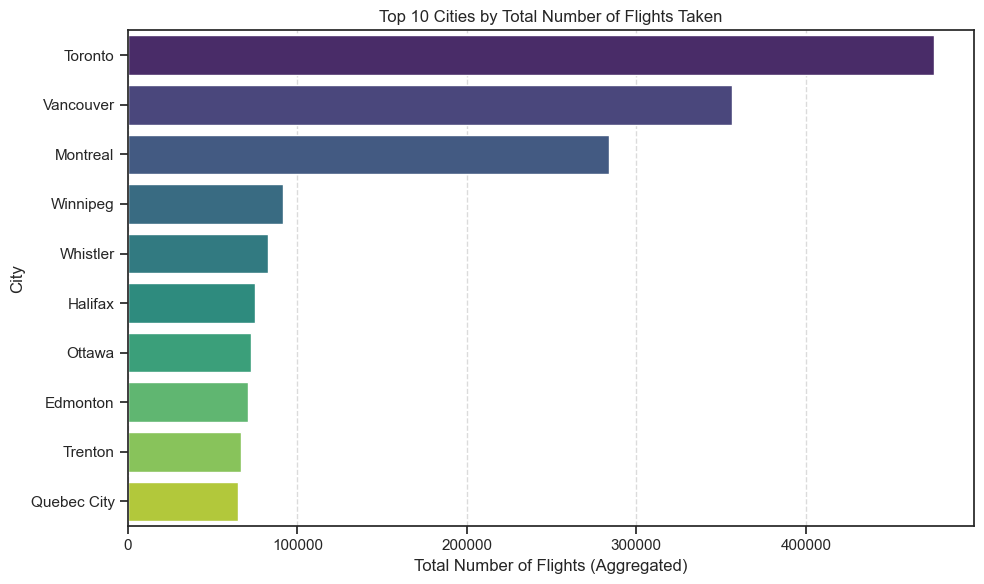

In [352]:
city_flights = customer_flights_combined.groupby('City')['NumFlights'].sum().reset_index()

# Rename the aggregated column for clarity
city_flights.columns = ['City', 'NumFlights_by_City']

# Sort the data and select the top 10 cities
top_10_cities = city_flights.sort_values(by='NumFlights_by_City', ascending=False).head(10)

# --- 2. CREATE BAR CHART ---

plt.figure(figsize=(10, 6))
# Use the aggregated column for the plot
sns.barplot(
    x='NumFlights_by_City',
    y='City',
    data=top_10_cities,
    palette='viridis' # Use a distinct color palette
)

plt.title('Top 10 Cities by Total Number of Flights Taken')
plt.xlabel('Total Number of Flights (Aggregated)')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/892103872.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


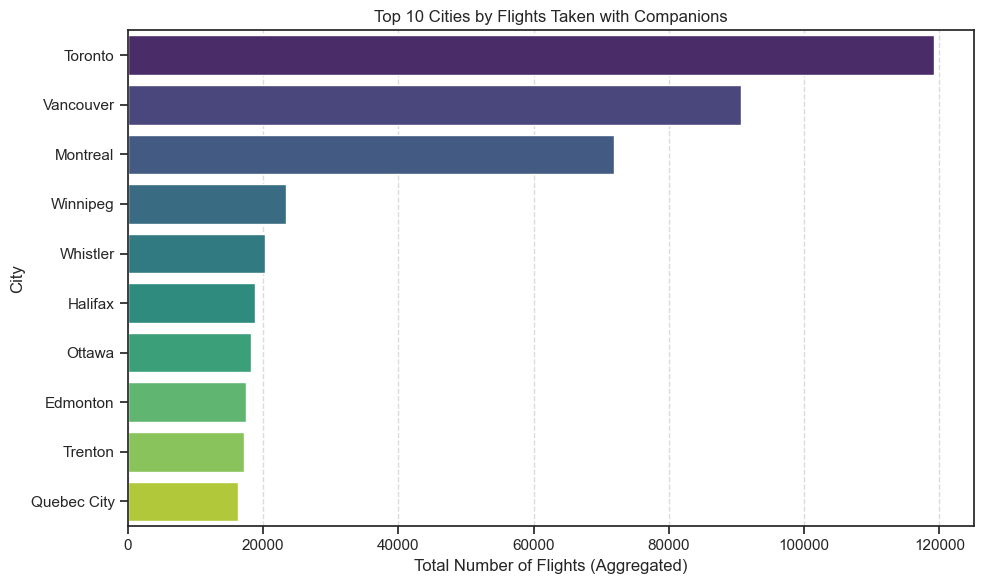

In [354]:
city_flights = customer_flights_combined.groupby('City')['NumFlightsWithCompanions'].sum().reset_index()

# Rename the aggregated column for clarity
city_flights.columns = ['City', 'NumFlightsWithCompanions_by_City']

# Sort the data and select the top 10 cities
top_10_cities = city_flights.sort_values(by='NumFlightsWithCompanions_by_City', ascending=False).head(10)

# --- 2. CREATE BAR CHART ---

plt.figure(figsize=(10, 6))
# Use the aggregated column for the plot
sns.barplot(
    x='NumFlightsWithCompanions_by_City',
    y='City',
    data=top_10_cities,
    palette='viridis' # Use a distinct color palette
)

plt.title('Top 10 Cities by Flights Taken with Companions')
plt.xlabel('Total Number of Flights (Aggregated)')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

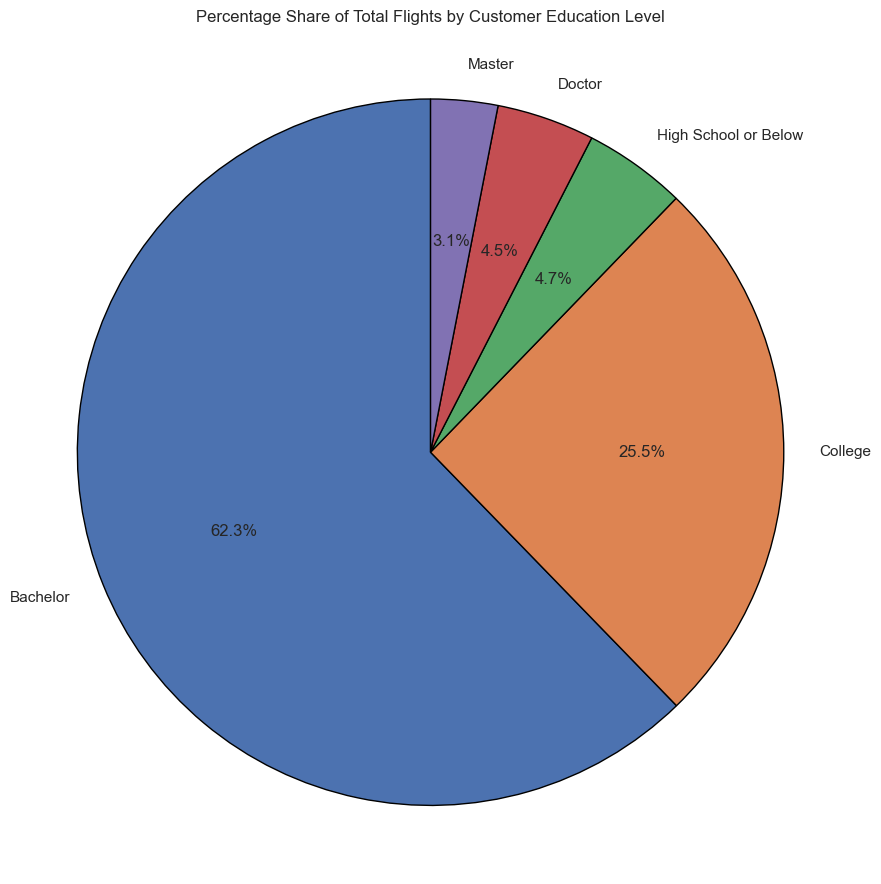

In [358]:
# --- 1. AGGREGATE DATA BY EDUCATION ---

# Group by Education and sum the NumFlights column
education_flights = customer_flights_combined.groupby('Education')['NumFlights'].sum().reset_index()

# Rename the aggregated column for clarity
education_flights.columns = ['Education', 'NumFlights_by_Education']

# Sort the data by flight volume descending
education_flights = education_flights.sort_values(by='NumFlights_by_Education', ascending=False)

# --- 2. CREATE BAR CHART ---
sizes = education_flights['NumFlights_by_Education']
labels = education_flights['Education']

# --- 2. CREATE PIE CHART ---

plt.figure(figsize=(9, 9))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',       # Display percentage format (e.g., 25.5%)
    startangle=90,           # Start the largest slice at the top
    wedgeprops={'edgecolor': 'black'} # Add a black border to slices
)

plt.title('Percentage Share of Total Flights by Customer Education Level')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()